In [1]:
import os
import yaml
import scanpy as sc
import muon as mu
import pandas as pd
import numpy as np
from scipy.stats import spearmanr
import seaborn as sns
import matplotlib.pyplot as plt

e:\Anaconda\envs\bio\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
e:\Anaconda\envs\bio\Lib\site-packages\muon\_core\preproc.py:31: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  if Version(scanpy.__version__) < Version("1.10"):


In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
path = "E://Biology//scRNA//Lee lab//E14S"

In [4]:
# Load pipeline parameters from YAML (override path with SPATIAL_ASSIGNING_CONFIG env var).
CONFIG_PATH = path + "/config.yaml"
with open(CONFIG_PATH, "r") as _f:
    CONFIG = yaml.safe_load(_f)
print(f"Loaded config from: {os.path.abspath(CONFIG_PATH)}")

# Derived barcode lists (shared across the notebook).
_bc_prefix = CONFIG["barcodes"]["prefix"]
rows = [f"{_bc_prefix}{i}" for i in range(CONFIG["barcodes"]["rows"]["start"],
                                          CONFIG["barcodes"]["rows"]["end"])]
cols = [f"{_bc_prefix}{i}" for i in range(CONFIG["barcodes"]["cols"]["start"],
                                          CONFIG["barcodes"]["cols"]["end"])]
ascend = CONFIG["barcodes"]["ascend"]

# Set random seed for reproducibility
SEED = int(CONFIG.get("seed", 42))
np.random.seed(SEED)
import random
random.seed(SEED)

Loaded config from: E:\Biology\scRNA\Lee lab\E14S\config.yaml


In [5]:
sample_id = CONFIG['sample_id']

In [6]:
mdata = mu.read_10x_h5(
   CONFIG["input"]["path"] + '//'+ CONFIG["input"]["h5_filename"],
)


In [7]:
mdata.var_names_make_unique()
mdata

MuData object with n_obs × n_vars = 5292 × 33888
  var:	'gene_ids', 'feature_types', 'genome', 'pattern', 'read', 'sequence'
  2 modalities
    rna:	5292 x 33696
      var:	'gene_ids', 'feature_types', 'genome', 'pattern', 'read', 'sequence'
    prot:	5292 x 192
      var:	'gene_ids', 'feature_types', 'genome', 'pattern', 'read', 'sequence'

In [8]:
# filtered_prot = mdata_raw['prot'][:, mdata_raw['prot'].var_names.str.startswith('sbc')]
# mdata_raw.mod['prot'] = filtered_prot
# filtered_prot = mdata['prot'][:, mdata['prot'].var_names.str.startswith('sbc')]
# mdata.mod['prot'] = filtered_prot

In [9]:
sbc_rna = mdata['rna'][:, mdata['rna'].var_names.str.startswith('Sgbc')]
sbc_rna.var_names

Index([], dtype='object')

In [10]:
mdata['rna'].var_names

Index(['Xkr4', 'Gm1992', 'Gm19938', 'Gm37381', 'Rp1', 'Sox17', 'Gm37587',
       'Gm37323', 'Mrpl15', 'A930006A01Rik',
       ...
       'Gm16367', 'ENSMUSG00000094172', 'ENSMUSG00000094887',
       'ENSMUSG00000091585', 'ENSMUSG00000095763', 'ENSMUSG00000095523',
       'ENSMUSG00000095475', 'ENSMUSG00000094855', 'ENSMUSG00000095019',
       'ENSMUSG00000095041'],
      dtype='object', length=33696)

In [11]:
from muon import prot as pt

In [12]:
prot_DF = mdata['prot'].to_df()
isV12 = CONFIG['version']['isV12']
isFirstHalf = CONFIG['version']['isFirstHalf']

# `rows`, `cols`, and `ascend` are built from CONFIG['barcodes'] in the
# config-loading cell near the top of the notebook.
cols_to_keep = [c for c in prot_DF.columns if c in rows or c in cols]
prot_DF_filtered = prot_DF[cols_to_keep]
prot_DF_filtered.head()



,sbc1,sbc2,sbc3,sbc4,sbc5,sbc6,sbc7,sbc8,sbc9,sbc10,...,sbc129,sbc130,sbc131,sbc132,sbc133,sbc134,sbc135,sbc136,sbc137,sbc138
AAACCAAAGGATGGCA-1,0.0,0.0,0.0,1.0,4285.0,3.0,1.0,8.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AAACCAAAGTCGATCA-1,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,...,2.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
AAACCAAAGTGAGCGA-1,0.0,2.0,0.0,1.0,10.0,1.0,1.0,48.0,1.0,1.0,...,0.0,0.0,1.0,0.0,1.0,2.0,0.0,0.0,0.0,0.0
AAACCCGCAATTCGCC-1,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AAACCCGCACTATCCA-1,0.0,0.0,399.0,4.0,9.0,1.0,0.0,8.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [13]:
BC_by_cell = prot_DF_filtered.where(prot_DF_filtered <= 1, 1)
BC_total = BC_by_cell.sum(axis = 0)

In [14]:
len(BC_total)

84

In [15]:
chunk = CONFIG['barcodes']['chunk']

r = list(rows)
c = list(cols)
if not ascend:
    r = r[::-1]
    c = c[::-1]

new_order = []
i = 0
while True:
    r_chunk = r[i * chunk : (i + 1) * chunk]
    c_chunk = c[i * chunk : (i + 1) * chunk]
    if not r_chunk and not c_chunk:
        break
    new_order.extend(r_chunk)
    new_order.extend(c_chunk)
    i += 1

BC_total_reordered = BC_total[new_order].to_list()

# X-axis: tick at start and end index of each row/col chunk along new_order
chunk_x_ticks = []
chunk_x_labels = []
pos = 0
i = 0
while True:
    r_chunk = r[i * chunk : (i + 1) * chunk]
    c_chunk = c[i * chunk : (i + 1) * chunk]
    if not r_chunk and not c_chunk:
        break
    if r_chunk:
        chunk_x_ticks.extend([pos, pos + len(r_chunk) - 1])
        chunk_x_labels.extend([str(r_chunk[0]), str(r_chunk[-1])])
        pos += len(r_chunk)
    if c_chunk:
        chunk_x_ticks.extend([pos, pos + len(c_chunk) - 1])
        chunk_x_labels.extend([str(c_chunk[0]), str(c_chunk[-1])])
        pos += len(c_chunk)
    i += 1

# BC_total = BC_total_reoredered

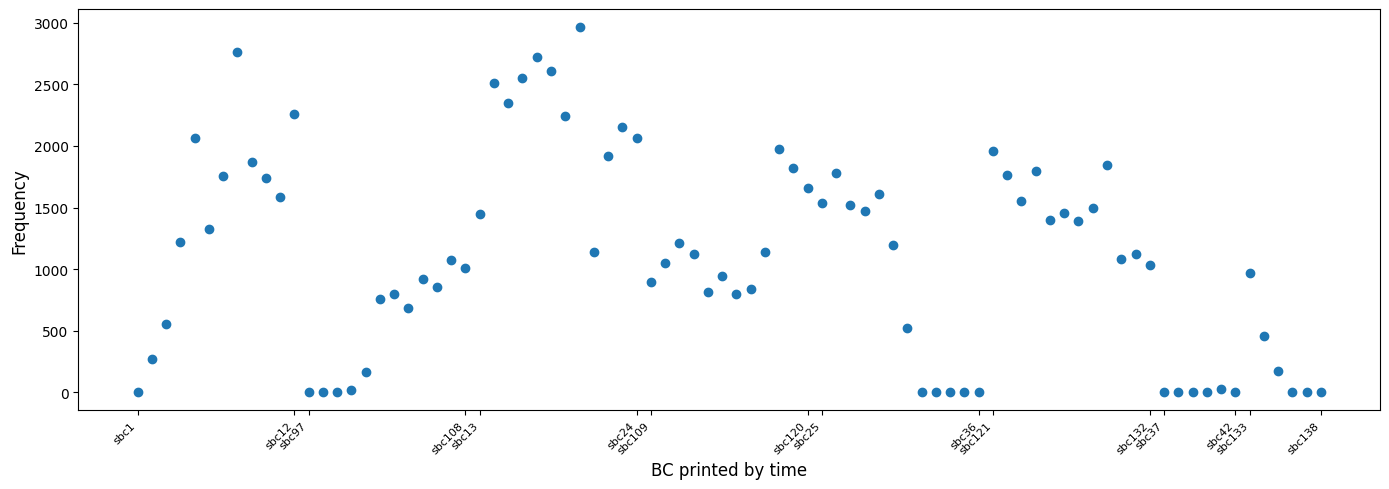

In [16]:
plt.figure(figsize=(14, 5))
plt.scatter(np.arange(len(BC_total_reordered)), np.array(BC_total_reordered))
plt.xticks(chunk_x_ticks, chunk_x_labels, rotation=45, ha="right", fontsize=8)
plt.xlabel("BC printed by time", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.tight_layout()

## load BC from gene

In [17]:
df = pd.DataFrame(index=rows, columns=cols)
for r in rows:
    for c in cols:
        df.loc[r, c] = f'{r}-{c}'

x = []
y = []

### Search with only 2 BCs

## Select top

In [18]:
# ratio = float(CONFIG['top_selection']['ratio'])

ratio = 1.4
suspect_list = list(CONFIG['top_selection']['suspect_list'])
suspect_multiplier = float(CONFIG['top_selection']['suspect_multiplier'])

def _top_name_and_confident(counts: pd.Series, order: list, fold: float,
                                suspect_sbcs=None, suspect_multiplier=1.0):
    s_full = pd.to_numeric(counts.reindex(order), errors="coerce").replace(0, np.nan)
    s = s_full.dropna()
    if s.empty:
        return None, False, pd.Series(dtype=float), pd.Series(dtype=np.float64)
    suspect_set = set(suspect_sbcs) if suspect_sbcs else set()
    tops = s.nlargest(min(3, len(s)))
    top1 = float(tops.iloc[0])
    top2 = float(tops.iloc[1]) if len(tops) > 1 else 0.0
    name = tops.index[0]
    if name in suspect_set:
        strict_fold = fold * suspect_multiplier
        if top1 < strict_fold * top2 and len(tops) > 1:
            name = tops.index[1]
            top1, top2 = float(tops.iloc[1]), float(tops.iloc[2]) if len(tops) > 2 else 0.0
    confident = top1 >= fold * top2
    i0 = order.index(name)
    detail = {}

    dist_ratio = {0: 1.0}
    for j, bc in enumerate(order):
        v = s_full.loc[bc]
        if pd.isna(v) or bc == name:
            continue
        detail[(bc, "ratio")] = float(v) / top1
        detail[(bc, "dist")] = j - i0
        dist_ratio[j - i0] = float(v) / top1
    dist_ratio_series = pd.Series(dist_ratio, dtype=np.float64).sort_index()
    
    return name, confident, pd.Series(detail), dist_ratio_series


df_cells = prot_DF_filtered

x, y, label, label_x, label_y = [], [], [], [], []  
ratio_rows = []
row_dr_rows = []
col_dr_rows = []
for bc in df_cells.index:
    name_x, cx, rx, dr_x = _top_name_and_confident(df_cells.loc[bc, rows], rows, ratio,
                                                     suspect_sbcs=suspect_list, suspect_multiplier=suspect_multiplier)
    name_y, cy, ry, dr_y = _top_name_and_confident(df_cells.loc[bc, cols], cols, ratio,
                                                     suspect_sbcs=suspect_list, suspect_multiplier=suspect_multiplier)
    x.append(name_x)
    y.append(name_y)
    label.append("confident" if (cx and cy) else "non-confident")
    label_x.append("x_confident" if cx else "x_non-confident")
    label_y.append("y_confident" if cy else "y_non-confident")
    row_dr_rows.append(dict(dr_x))
    col_dr_rows.append(dict(dr_y))
    
ratio_df = pd.DataFrame(ratio_rows, index=df_cells.index)
row_dist_ratio_df = pd.DataFrame(row_dr_rows, index=df_cells.index)
col_dist_ratio_df = pd.DataFrame(col_dr_rows, index=df_cells.index)
xy_raw = pd.DataFrame({"x": x, "y": y, "label": label}, index=df_cells.index)


In [19]:
from collections import Counter
counts = Counter(label_x)
print(counts['x_confident'])  # 3
print(counts['x_non-confident'])  # 2

countsy = Counter(label_y)
print(countsy['y_confident'])  # 3
print(countsy['y_non-confident'])  # 2

3481
1811
3428
1864


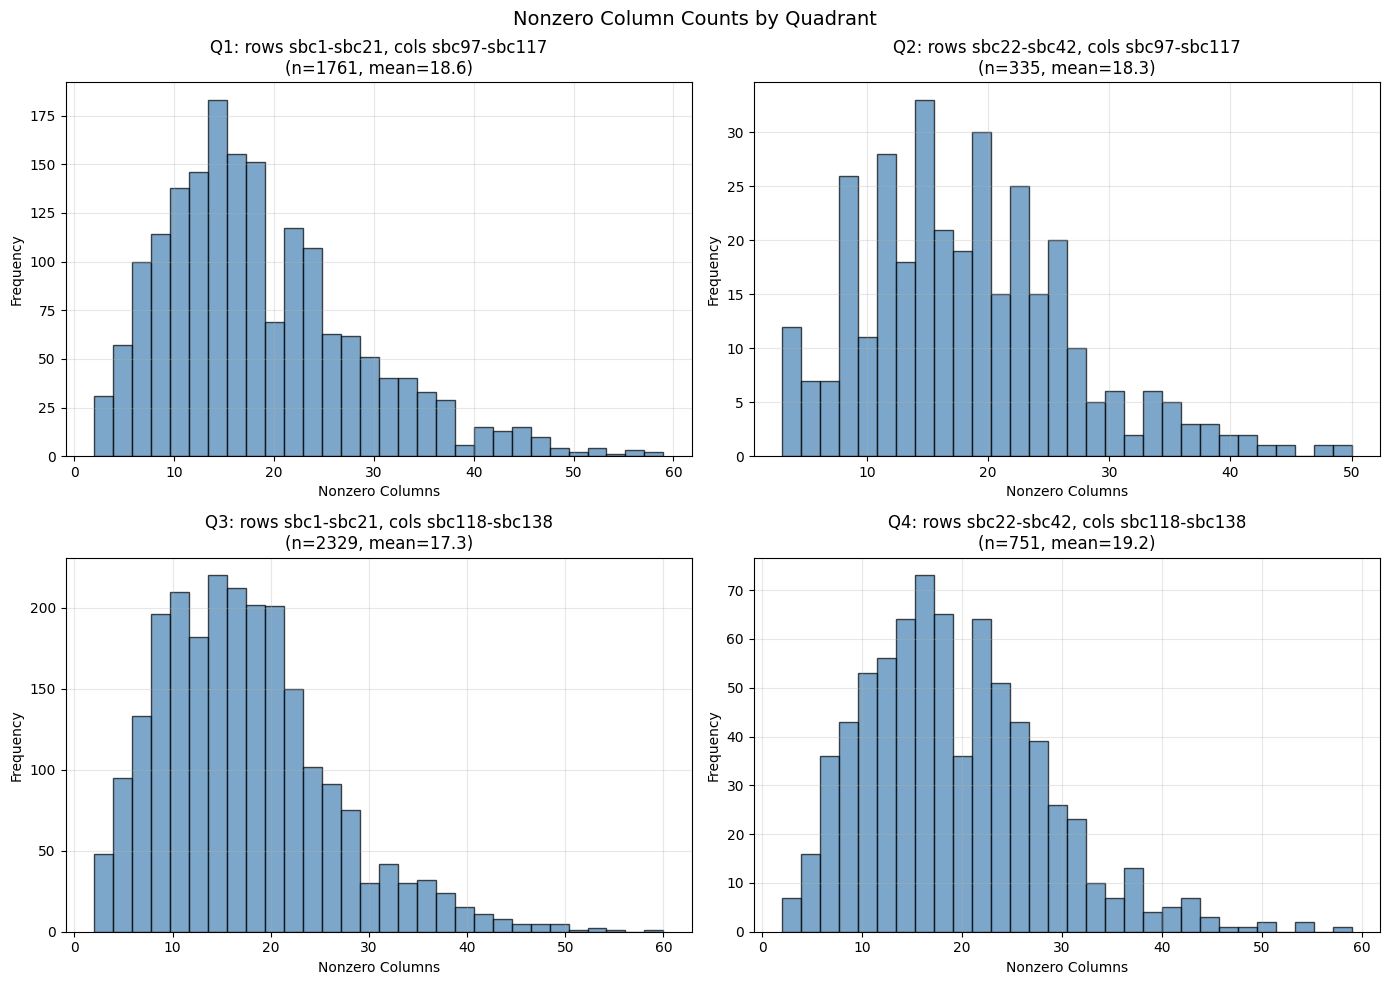

In [20]:
mid_row = len(rows) // 2
mid_col = len(cols) // 2
first_rows = set(rows[:mid_row])
second_rows = set(rows[mid_row:])
first_cols = set(cols[:mid_col])
second_cols = set(cols[mid_col:])

xy_valid = xy_raw.dropna(subset=["x", "y"])
quadrant_labels = {}
for cell_id, row in xy_valid.iterrows():
    x_val, y_val = row["x"], row["y"]
    if x_val in first_rows and y_val in first_cols:
        quadrant_labels[cell_id] = "Q1"
    elif x_val in second_rows and y_val in first_cols:
        quadrant_labels[cell_id] = "Q2"
    elif x_val in first_rows and y_val in second_cols:
        quadrant_labels[cell_id] = "Q3"
    elif x_val in second_rows and y_val in second_cols:
        quadrant_labels[cell_id] = "Q4"

quadrant_series = pd.Series(quadrant_labels)
nonzero_col_counts = (prot_DF_filtered != 0).sum(axis=1)

fig, axes = plt.subplots(2, 2, figsize=(14, 10), dpi=100)
quadrant_info = [
    ("Q1", f"rows {rows[0]}-{rows[mid_row-1]}, cols {cols[0]}-{cols[mid_col-1]}"),
    ("Q2", f"rows {rows[mid_row]}-{rows[-1]}, cols {cols[0]}-{cols[mid_col-1]}"),
    ("Q3", f"rows {rows[0]}-{rows[mid_row-1]}, cols {cols[mid_col]}-{cols[-1]}"),
    ("Q4", f"rows {rows[mid_row]}-{rows[-1]}, cols {cols[mid_col]}-{cols[-1]}"),
]

for ax, (q_name, q_desc) in zip(axes.flatten(), quadrant_info):
    mask = quadrant_series == q_name
    q_cells = quadrant_series.index[mask]
    q_counts = nonzero_col_counts.reindex(q_cells).dropna()
    ax.hist(q_counts, bins=30, edgecolor='black', alpha=0.7, color='steelblue')
    ax.set_xlabel('Nonzero Columns')
    ax.set_ylabel('Frequency')
    ax.set_title(f'{q_name}: {q_desc}\n(n={len(q_counts)}, mean={q_counts.mean():.1f})')
    ax.grid(True, alpha=0.3)

plt.suptitle('Nonzero Column Counts by Quadrant', fontsize=14)
plt.tight_layout()
plt.show()

In [21]:
# Average cells per spatial (row_bc, col_bc) combination within each quadrant
confident_mask = xy_valid['label'] == 'confident'
_xyq = xy_valid[confident_mask].copy()

_xyq["quadrant"] = _xyq.index.map(quadrant_series)

avg_cells_per_bc_combo = []
for q_name in ["Q1", "Q2", "Q3", "Q4"]:
    sub = _xyq[_xyq["quadrant"] == q_name]
    n_cells = len(sub)
    combo_counts = sub.groupby(["x", "y"]).size()
    n_unique_combos = combo_counts.shape[0]
    avg_cells = (n_cells / n_unique_combos) if n_unique_combos else np.nan
    avg_cells_per_bc_combo.append(
        {
            "quadrant": q_name,
            "n_cells": n_cells,
            "n_wells": n_unique_combos,
            "avg_cells_per_well": avg_cells,
        }
    )

avg_bc_combo_by_quadrant = pd.DataFrame(avg_cells_per_bc_combo)
display(avg_bc_combo_by_quadrant)


,quadrant,n_cells,n_wells,avg_cells_per_well
0,Q1,754,219,3.442922
1,Q2,171,64,2.671875
2,Q3,1011,253,3.996047
3,Q4,515,130,3.961538


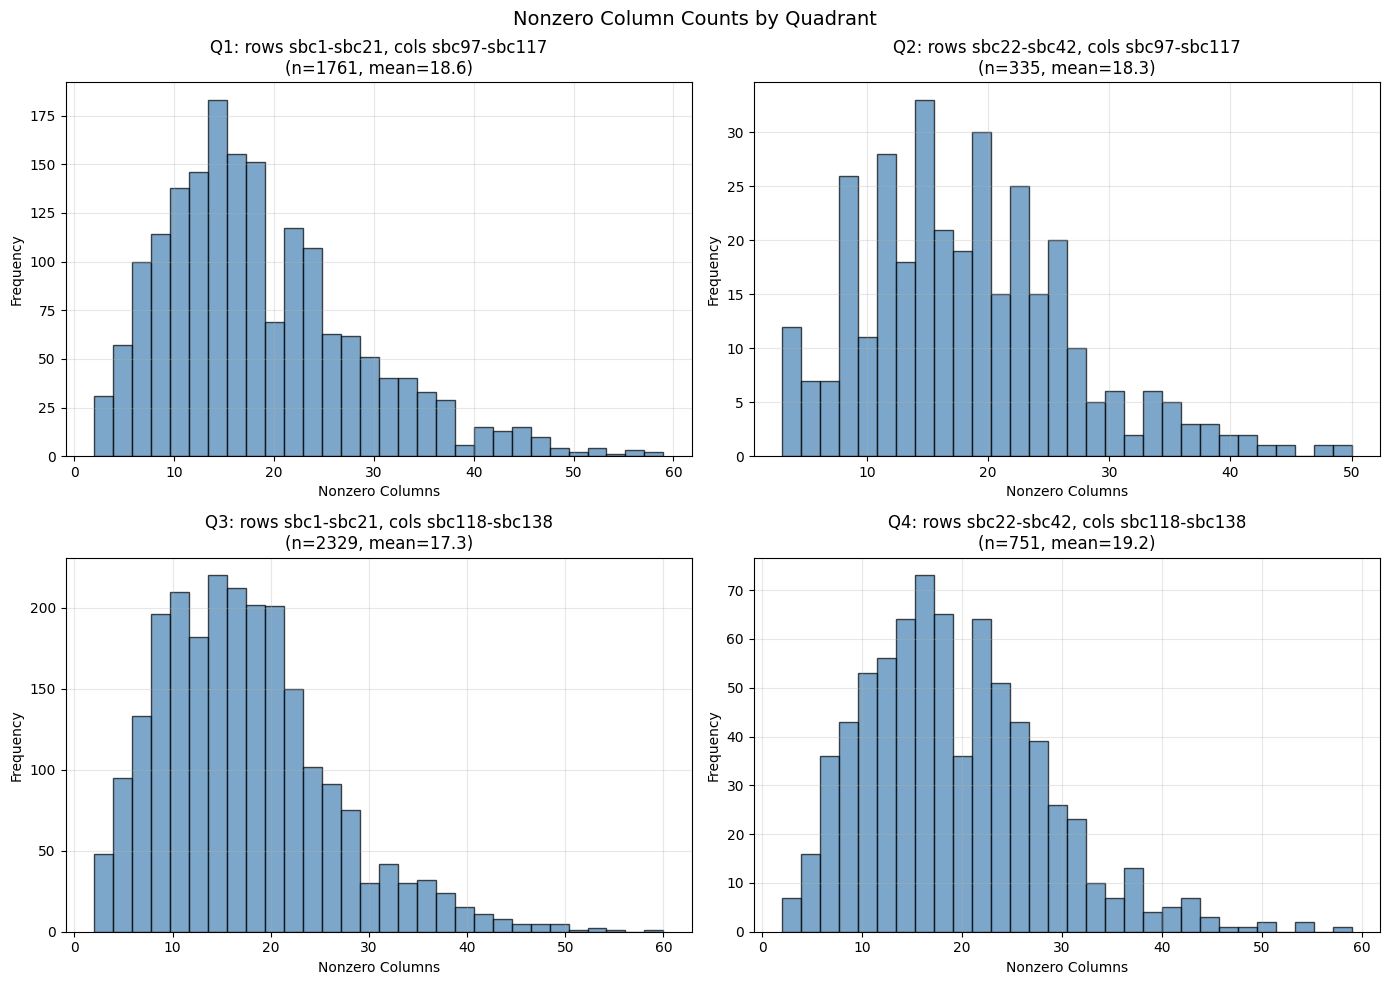

In [22]:
mid_row = len(rows) // 2
mid_col = len(cols) // 2
first_rows = set(rows[:mid_row])
second_rows = set(rows[mid_row:])
first_cols = set(cols[:mid_col])
second_cols = set(cols[mid_col:])

xy_valid = xy_raw.dropna(subset=["x", "y"])
quadrant_labels = {}
for cell_id, row in xy_valid.iterrows():
    x_val, y_val = row["x"], row["y"]
    if x_val in first_rows and y_val in first_cols:
        quadrant_labels[cell_id] = "Q1"
    elif x_val in second_rows and y_val in first_cols:
        quadrant_labels[cell_id] = "Q2"
    elif x_val in first_rows and y_val in second_cols:
        quadrant_labels[cell_id] = "Q3"
    elif x_val in second_rows and y_val in second_cols:
        quadrant_labels[cell_id] = "Q4"

quadrant_series = pd.Series(quadrant_labels)
nonzero_col_counts = (prot_DF_filtered != 0).sum(axis=1)

fig, axes = plt.subplots(2, 2, figsize=(14, 10), dpi=100)
quadrant_info = [
    ("Q1", f"rows {rows[0]}-{rows[mid_row-1]}, cols {cols[0]}-{cols[mid_col-1]}"),
    ("Q2", f"rows {rows[mid_row]}-{rows[-1]}, cols {cols[0]}-{cols[mid_col-1]}"),
    ("Q3", f"rows {rows[0]}-{rows[mid_row-1]}, cols {cols[mid_col]}-{cols[-1]}"),
    ("Q4", f"rows {rows[mid_row]}-{rows[-1]}, cols {cols[mid_col]}-{cols[-1]}"),
]

for ax, (q_name, q_desc) in zip(axes.flatten(), quadrant_info):
    mask = quadrant_series == q_name
    q_cells = quadrant_series.index[mask]
    q_counts = nonzero_col_counts.reindex(q_cells).dropna()
    ax.hist(q_counts, bins=30, edgecolor='black', alpha=0.7, color='steelblue')
    ax.set_xlabel('Nonzero Columns')
    ax.set_ylabel('Frequency')
    ax.set_title(f'{q_name}: {q_desc}\n(n={len(q_counts)}, mean={q_counts.mean():.1f})')
    ax.grid(True, alpha=0.3)

plt.suptitle('Nonzero Column Counts by Quadrant', fontsize=14)
plt.tight_layout()
plt.show()

In [23]:
row_dist_ratio_df = row_dist_ratio_df[sorted(row_dist_ratio_df.columns)]
row_dist_ratio_df = row_dist_ratio_df.fillna(0)

col_dist_ratio_df = col_dist_ratio_df[sorted(col_dist_ratio_df.columns)]
col_dist_ratio_df = col_dist_ratio_df.fillna(0)

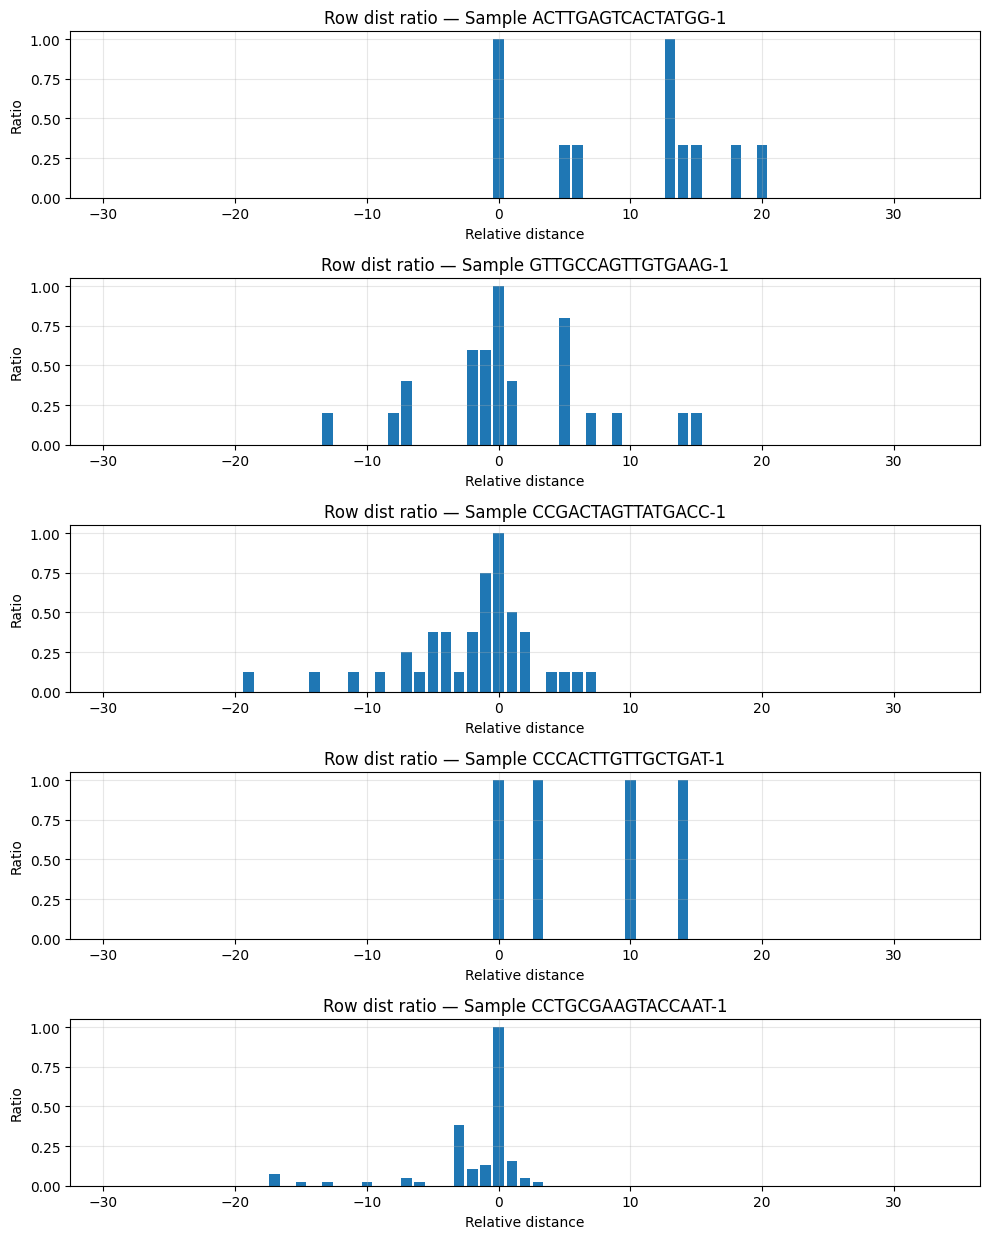

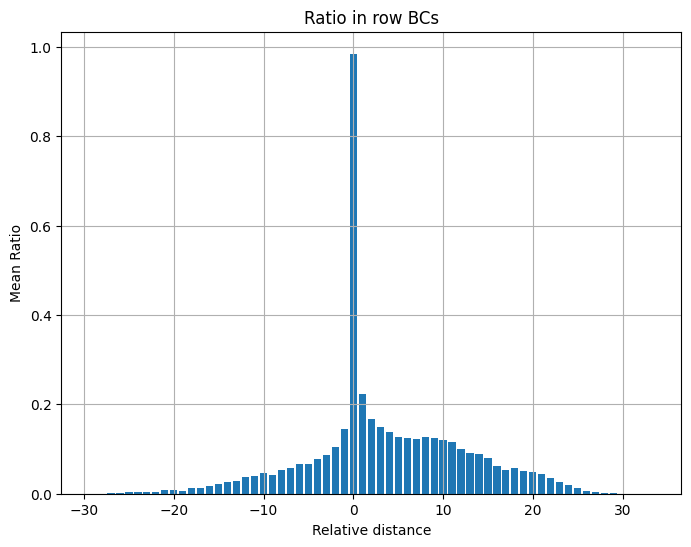

In [24]:
confident_mask = xy_raw['label'] != 'confident'
common_idx = row_dist_ratio_df.index.intersection(xy_raw[confident_mask].index)
row_dist_ratio_filtered = row_dist_ratio_df.loc[common_idx]

k = 5  # or choose your desired k
sampled_rows = row_dist_ratio_filtered.sample(n=k, random_state=42)

plt.figure(figsize=(10, 2.5 * k))
for i, (idx, row) in enumerate(sampled_rows.iterrows(), 1):
    plt.subplot(k, 1, i)
    plt.bar(row.index, row.values, width=0.8)
    plt.title(f"Row dist ratio — Sample {idx}")
    plt.xlabel("Relative distance")
    plt.ylabel("Ratio")
    plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

a = row_dist_ratio_filtered.mean(axis=0)
plt.figure(figsize=(8,6))
plt.bar(a.index, a.values, width=0.8)
plt.xlabel("Relative distance")
plt.ylabel("Mean Ratio")
plt.title("Ratio in row BCs")
plt.grid(True)
plt.show()     

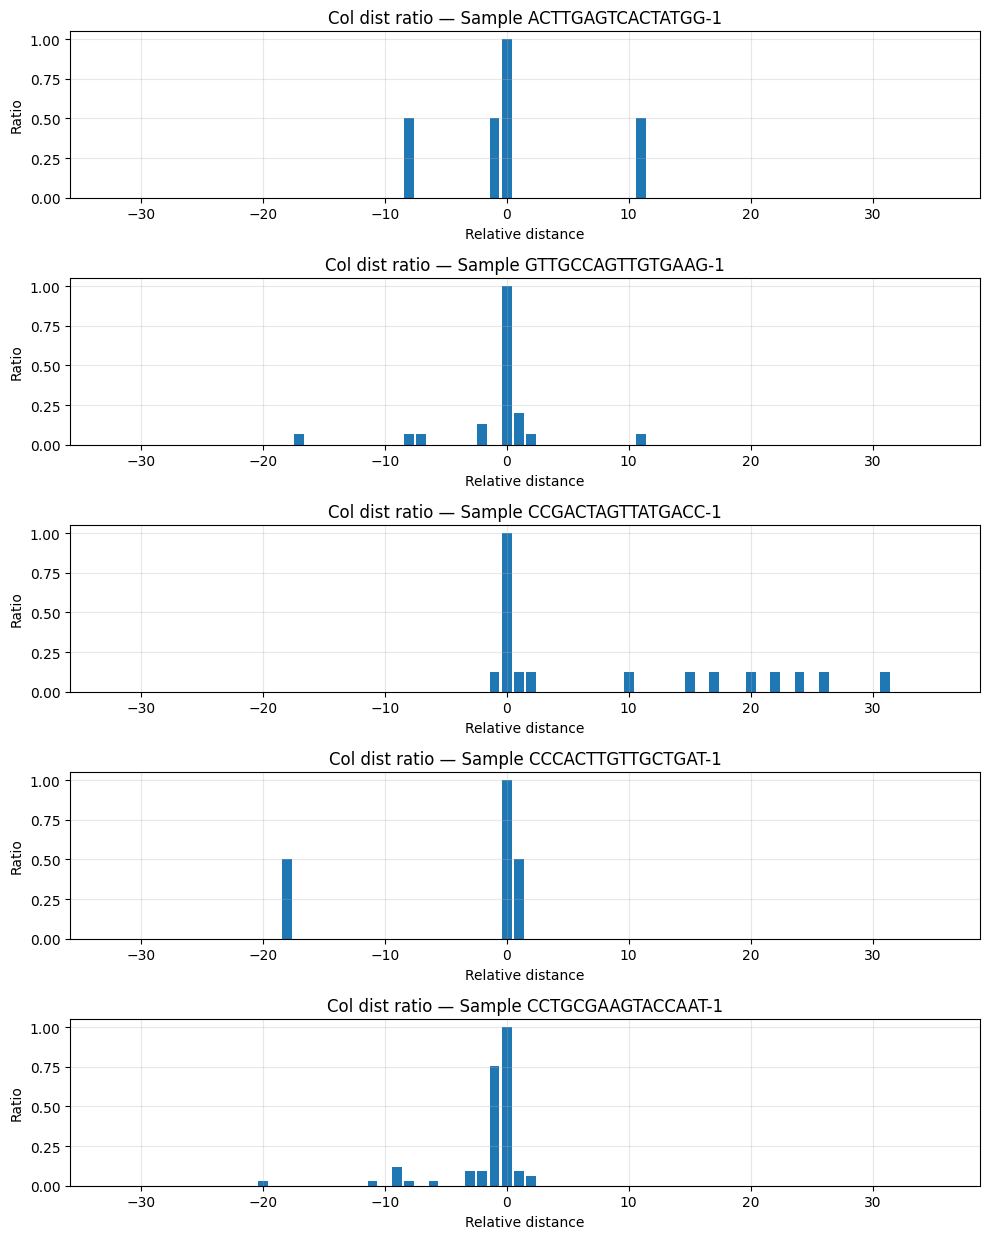

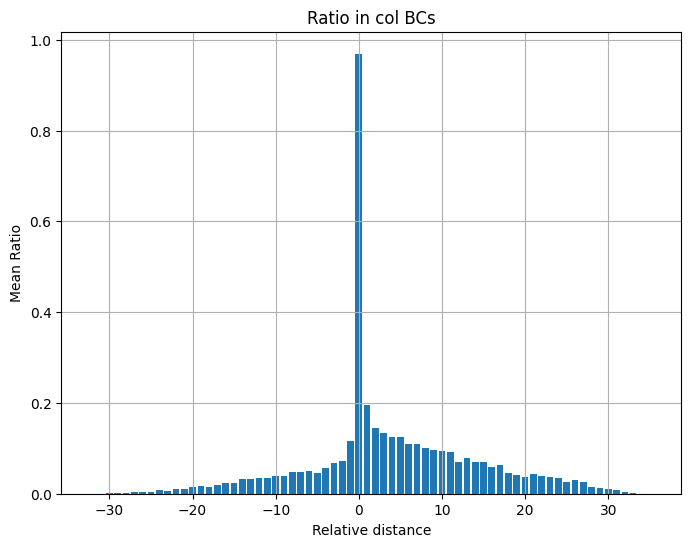

In [ ]:
col_dist_ratio_filtered = col_dist_ratio_df.loc[common_idx]
sampled_cols = col_dist_ratio_filtered.sample(n=k, random_state=42)

plt.figure(figsize=(10, 2.5 * k))
for i, (idx, row) in enumerate(sampled_cols.iterrows(), 1):
    plt.subplot(k, 1, i)
    plt.bar(row.index, row.values, width=0.8)
    plt.title(f"Col dist ratio — Sample {idx}")
    plt.xlabel("Relative distance")
    plt.ylabel("Ratio")
    plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

b = col_dist_ratio_filtered.mean(axis=0)
plt.figure(figsize=(8,6))
plt.bar(b.index, b.values, width=0.8)
plt.xlabel("Relative distance")
plt.ylabel("Mean Ratio")
plt.title("Ratio in col BCs")
plt.grid(True)
plt.show()     

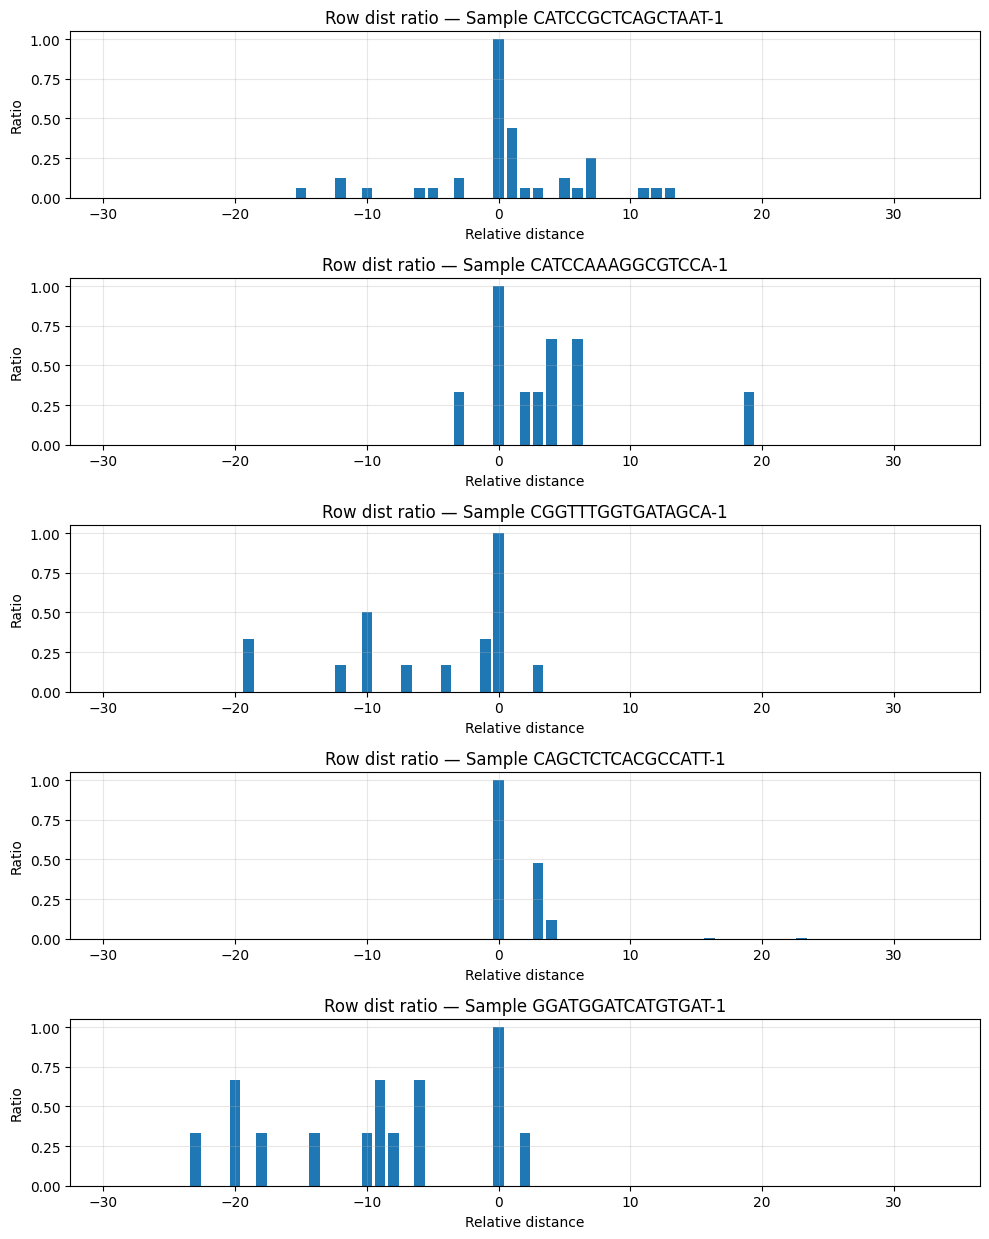

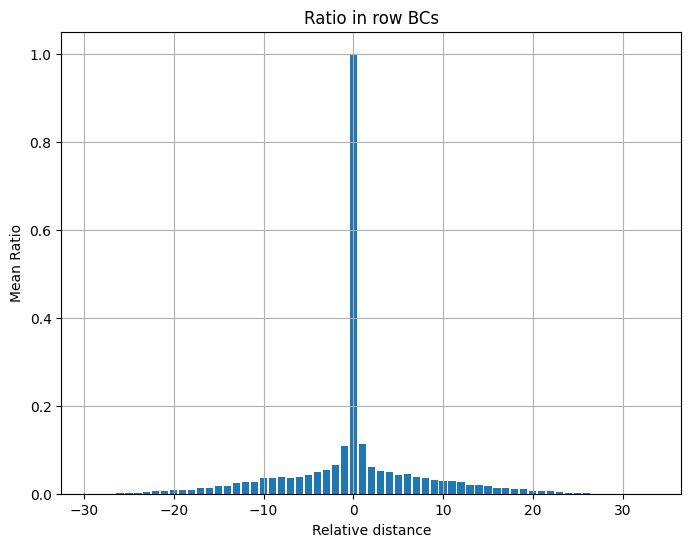

In [26]:
# The other set
confident_mask = xy_raw['label'] == 'confident'
common_idx = row_dist_ratio_df.index.intersection(xy_raw[confident_mask].index)
row_dist_ratio_filtered = row_dist_ratio_df.loc[common_idx]
k = 5  # or choose your desired k
sampled_rows = row_dist_ratio_filtered.sample(n=k, random_state=42)

plt.figure(figsize=(10, 2.5 * k))
for i, (idx, row) in enumerate(sampled_rows.iterrows(), 1):
    plt.subplot(k, 1, i)
    plt.bar(row.index, row.values, width=0.8)
    plt.title(f"Row dist ratio — Sample {idx}")
    plt.xlabel("Relative distance")
    plt.ylabel("Ratio")
    plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


a = row_dist_ratio_filtered.mean(axis=0)
plt.figure(figsize=(8,6))
plt.bar(a.index, a.values, width=0.8)
plt.xlabel("Relative distance")
plt.ylabel("Mean Ratio")
plt.title("Ratio in row BCs")
plt.grid(True)
plt.show()     


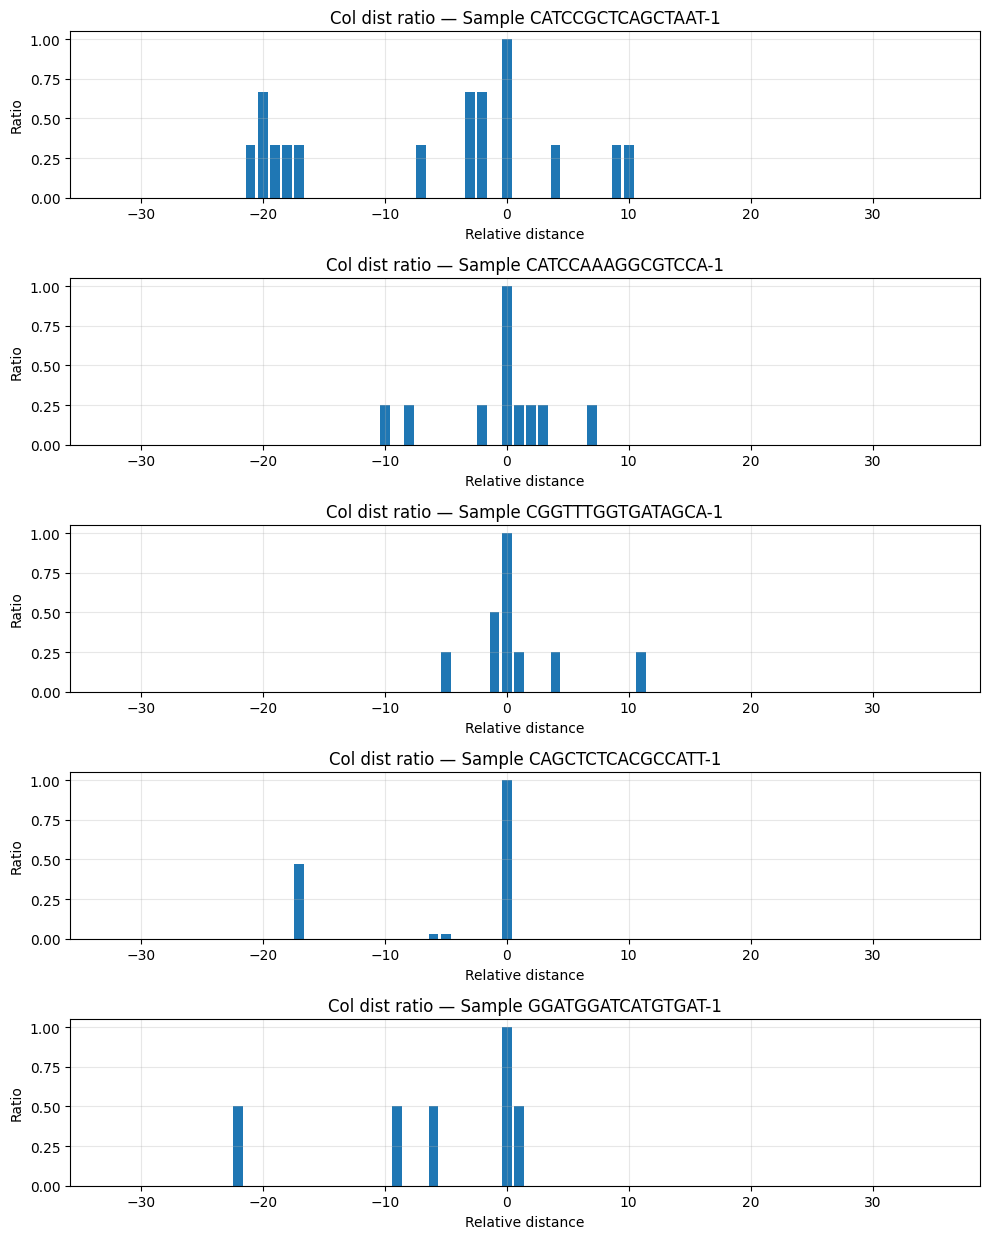

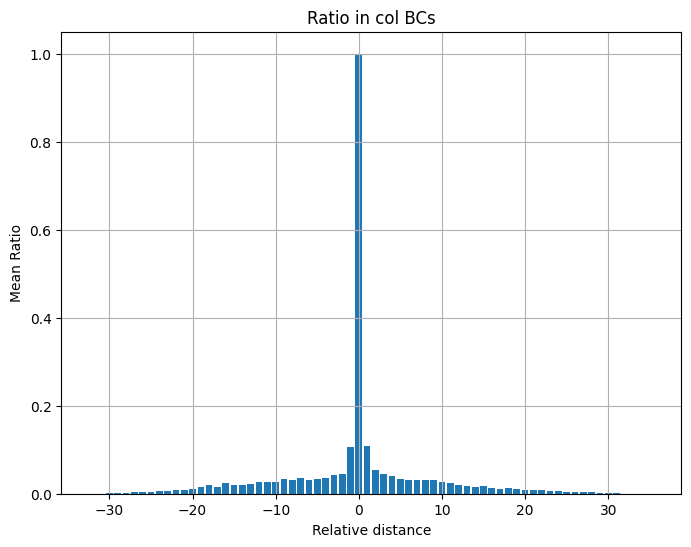

In [27]:
col_dist_ratio_filtered = col_dist_ratio_df.loc[common_idx]

k = 5  # or choose your desired k
sampled_col = col_dist_ratio_filtered.sample(n=k, random_state=42)

plt.figure(figsize=(10, 2.5 * k))
for i, (idx, row) in enumerate(sampled_col.iterrows(), 1):
    plt.subplot(k, 1, i)
    plt.bar(row.index, row.values, width=0.8)
    plt.title(f"Col dist ratio — Sample {idx}")
    plt.xlabel("Relative distance")
    plt.ylabel("Ratio")
    plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


a = col_dist_ratio_filtered.mean(axis=0)
plt.figure(figsize=(8,6))
plt.bar(a.index, a.values, width=0.8)
plt.xlabel("Relative distance")
plt.ylabel("Mean Ratio")
plt.title("Ratio in col BCs")
plt.grid(True)
plt.show()     

In [29]:
def _top3_rel_dist(dist_row):
    """Top 3 relative distances separately for negative and positive index sides.

    Negative indices = earlier barcodes (rows: Q1/Q2 direction; cols: Q1/Q3 direction).
    Positive indices = later barcodes  (rows: Q3/Q4 direction; cols: Q2/Q4 direction).
    Ties at the same absolute distance within a side are averaged.
    """
    s = pd.to_numeric(dist_row, errors="coerce").dropna()
    if 0 in s.index:
        s = s.drop(0)
    s = s[s > 0]  # keep only non-zero ratio values

    def _top3_side(side_s):
        if side_s.empty:
            return [np.nan, np.nan, np.nan]
        sorted_s = side_s.sort_values(ascending=False)
        ranks = []
        i = 0
        while len(ranks) < 3 and i < len(sorted_s):
            ratio = sorted_s.iloc[i]
            tied = sorted_s[sorted_s == ratio]
            ranks.append(float(np.mean(np.abs(tied.index.astype(float)))))
            i += len(tied)
        while len(ranks) < 3:
            ranks.append(np.nan)
        return ranks

    idx_f = s.index.astype(float)
    neg_ranks = _top3_side(s[idx_f < 0])
    pos_ranks = _top3_side(s[idx_f > 0])

    return pd.Series({
        "neg_rank1": neg_ranks[0], "neg_rank2": neg_ranks[1], "neg_rank3": neg_ranks[2],
        "pos_rank1": pos_ranks[0], "pos_rank2": pos_ranks[1], "pos_rank3": pos_ranks[2],
    })


def _top3_rel_dist_by_quadrant(dist_ratio_df, label_mask, axis="row"):
    """Aggregate per-barcode top-3 distances grouped by spatial half.

    axis='row': compares Q1+Q2 (first col half) vs Q3+Q4 (second col half).
    axis='col': compares Q1+Q3 (first row half) vs Q2+Q4 (second row half).
    """
    idx = dist_ratio_df.index.intersection(xy_raw.index[label_mask])
    sub = dist_ratio_df.loc[idx].copy()
    sub["quadrant"] = sub.index.map(quadrant_series)
    sub = sub.dropna(subset=["quadrant"])

    top3 = sub.drop(columns="quadrant").apply(_top3_rel_dist, axis=1)
    top3["quadrant"] = sub["quadrant"].values

    if axis == "row":
        group_map = {"Q1": "Q1+Q2", "Q2": "Q1+Q2", "Q3": "Q3+Q4", "Q4": "Q3+Q4"}
        group_order = ["Q1+Q2", "Q3+Q4"]
    else:
        group_map = {"Q1": "Q1+Q3", "Q2": "Q2+Q4", "Q3": "Q1+Q3", "Q4": "Q2+Q4"}
        group_order = ["Q1+Q3", "Q2+Q4"]

    top3["group"] = top3["quadrant"].map(group_map)
    rank_cols = ["neg_rank1", "neg_rank2", "neg_rank3", "pos_rank1", "pos_rank2", "pos_rank3"]
    return (
        top3.groupby("group")[rank_cols]
        .mean()
        .reindex(group_order)
    )


conf_mask = xy_raw["label"] == "confident"
nonconf_mask = xy_raw["label"] == "non-confident"

row_top3_dist_confident_q = _top3_rel_dist_by_quadrant(row_dist_ratio_df, conf_mask, axis="row")
row_top3_dist_nonconfident_q = _top3_rel_dist_by_quadrant(row_dist_ratio_df, nonconf_mask, axis="row")
col_top3_dist_confident_q = _top3_rel_dist_by_quadrant(col_dist_ratio_df, conf_mask, axis="col")
col_top3_dist_nonconfident_q = _top3_rel_dist_by_quadrant(col_dist_ratio_df, nonconf_mask, axis="col")


In [30]:
display(row_top3_dist_confident_q.round(2))
# display(row_top3_dist_nonconfident_q.round(2))
display(col_top3_dist_confident_q.round(2))
# display(col_top3_dist_nonconfident_q.round(2))

,neg_rank1,neg_rank2,neg_rank3,pos_rank1,pos_rank2,pos_rank3
group,,,,,,
Q1+Q2,3.76,5.13,6.75,4.4,6.21,7.41
Q3+Q4,6.14,7.69,8.56,5.2,6.60,7.11


,neg_rank1,neg_rank2,neg_rank3,pos_rank1,pos_rank2,pos_rank3
group,,,,,,
Q1+Q3,6.55,7.69,8.38,7.20,9.18,10.07
Q2+Q4,6.29,7.48,8.48,4.82,6.60,7.32


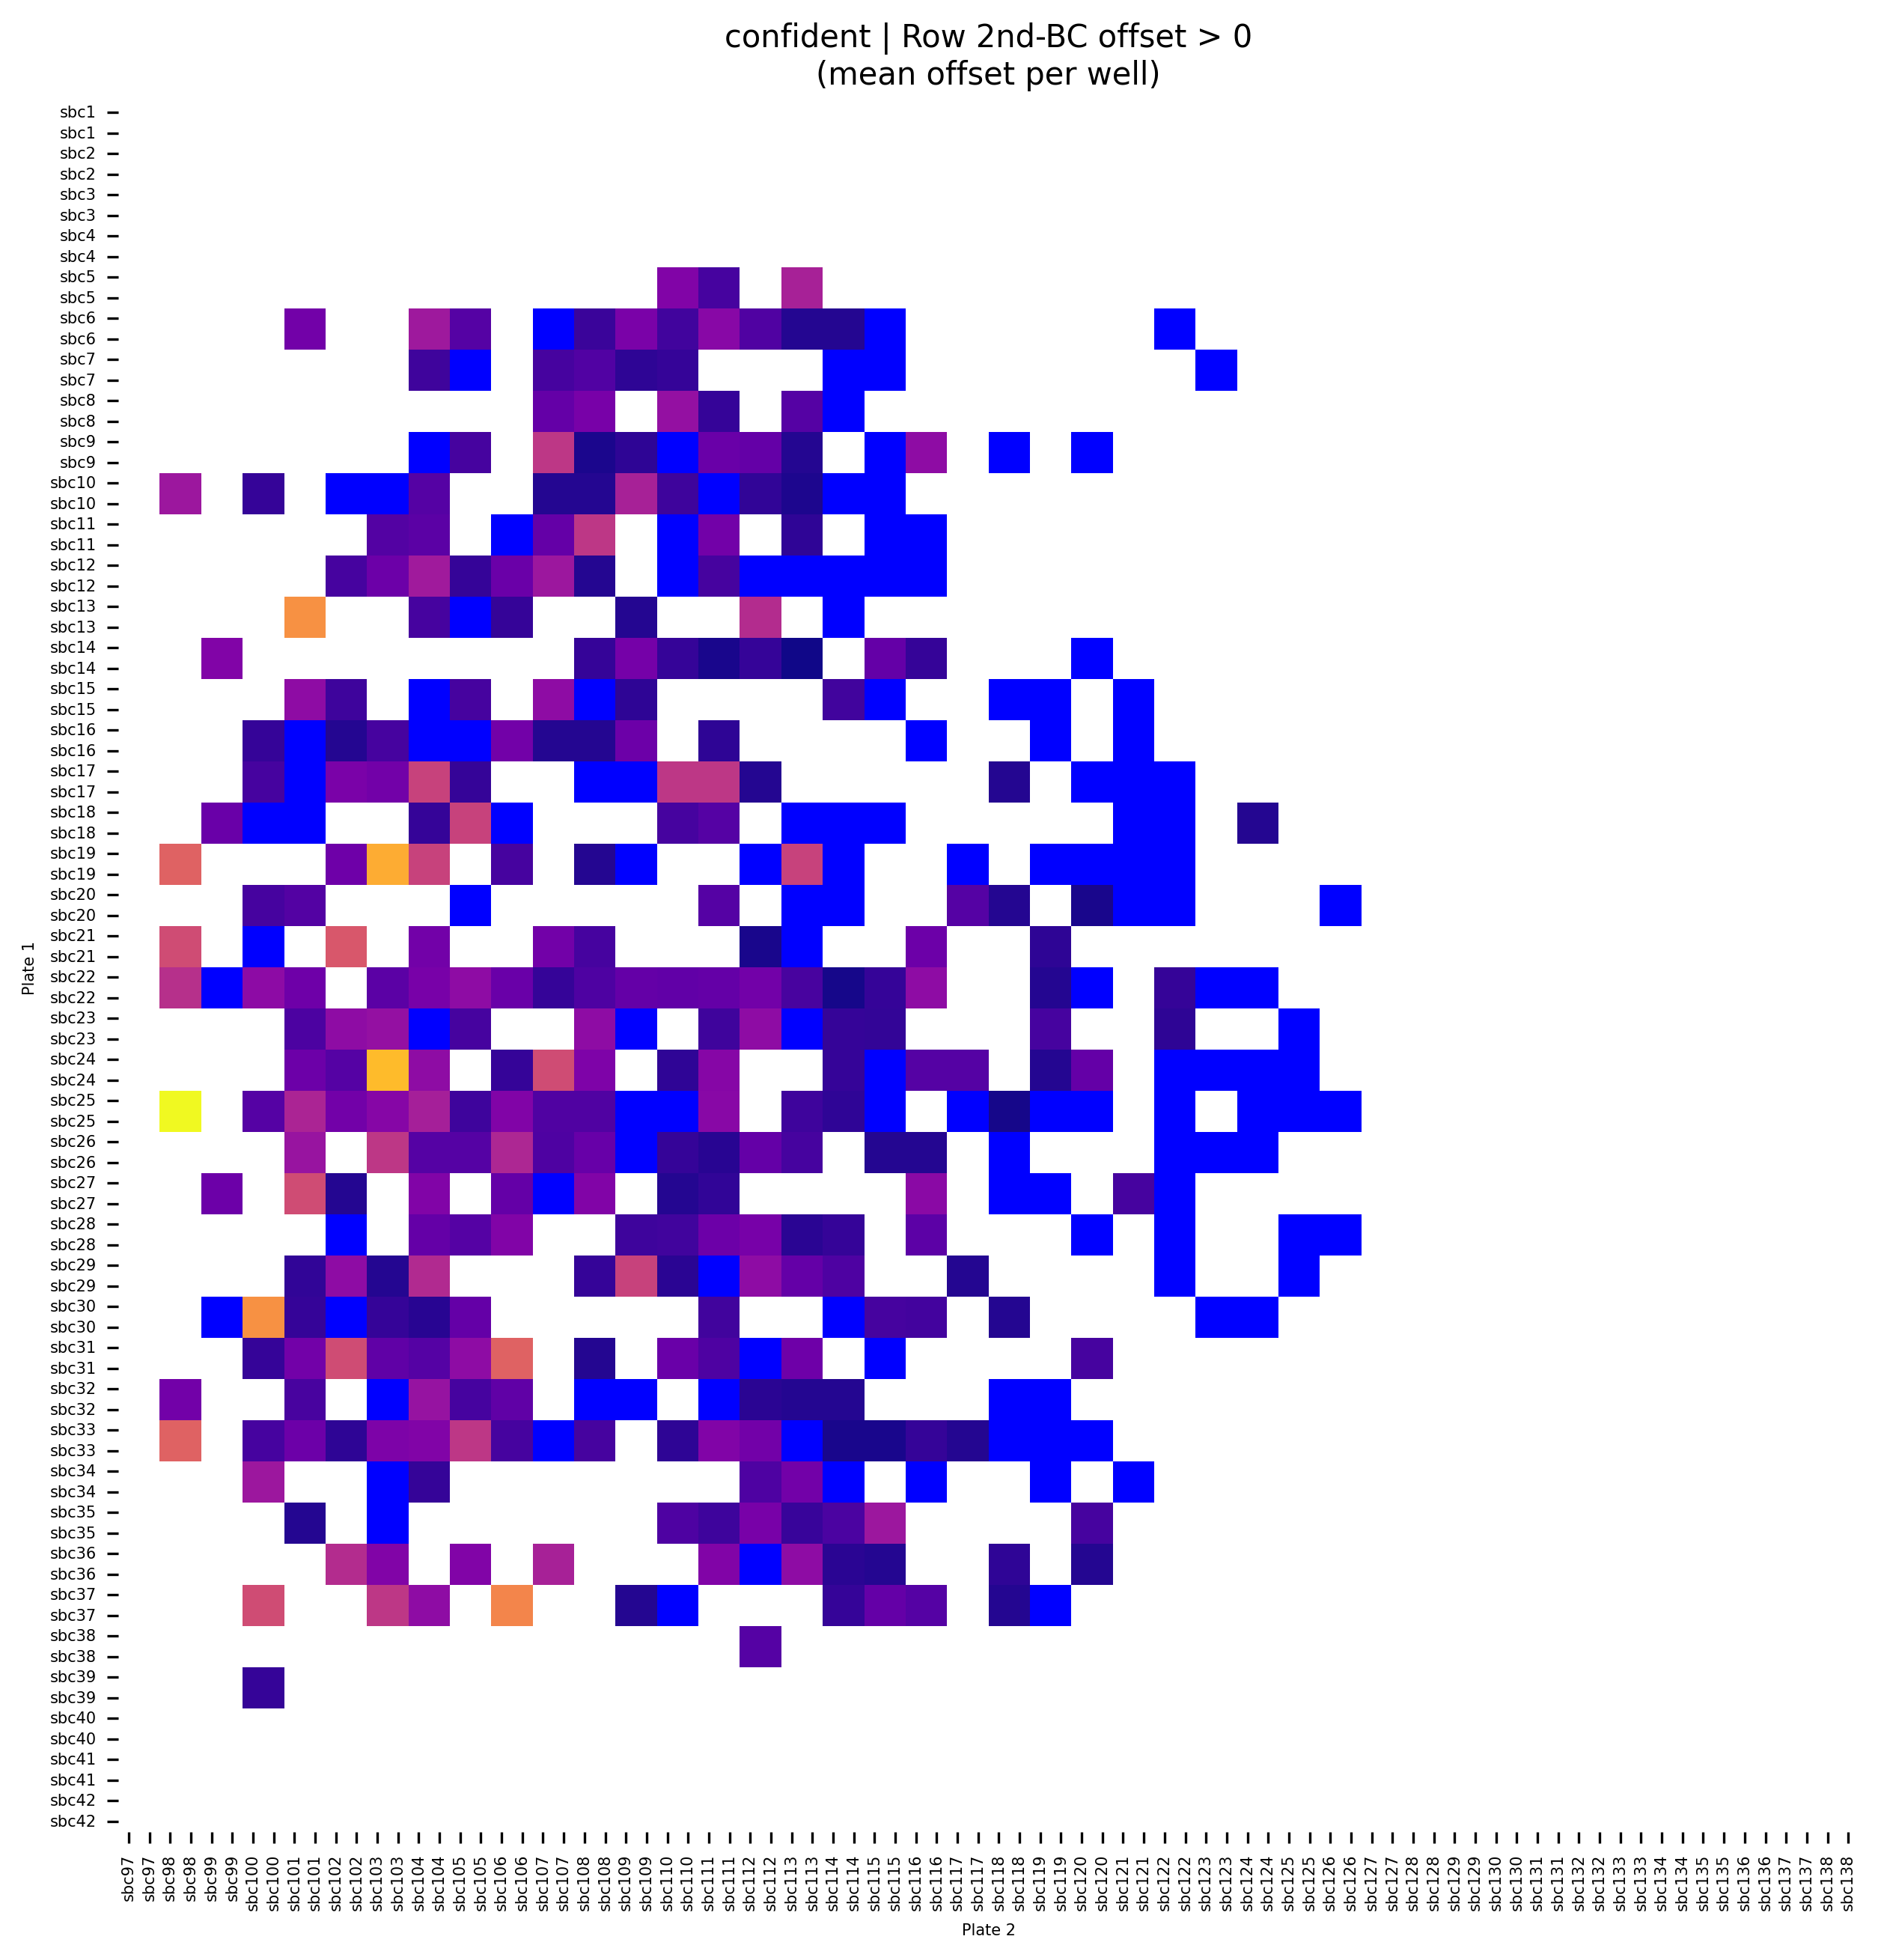

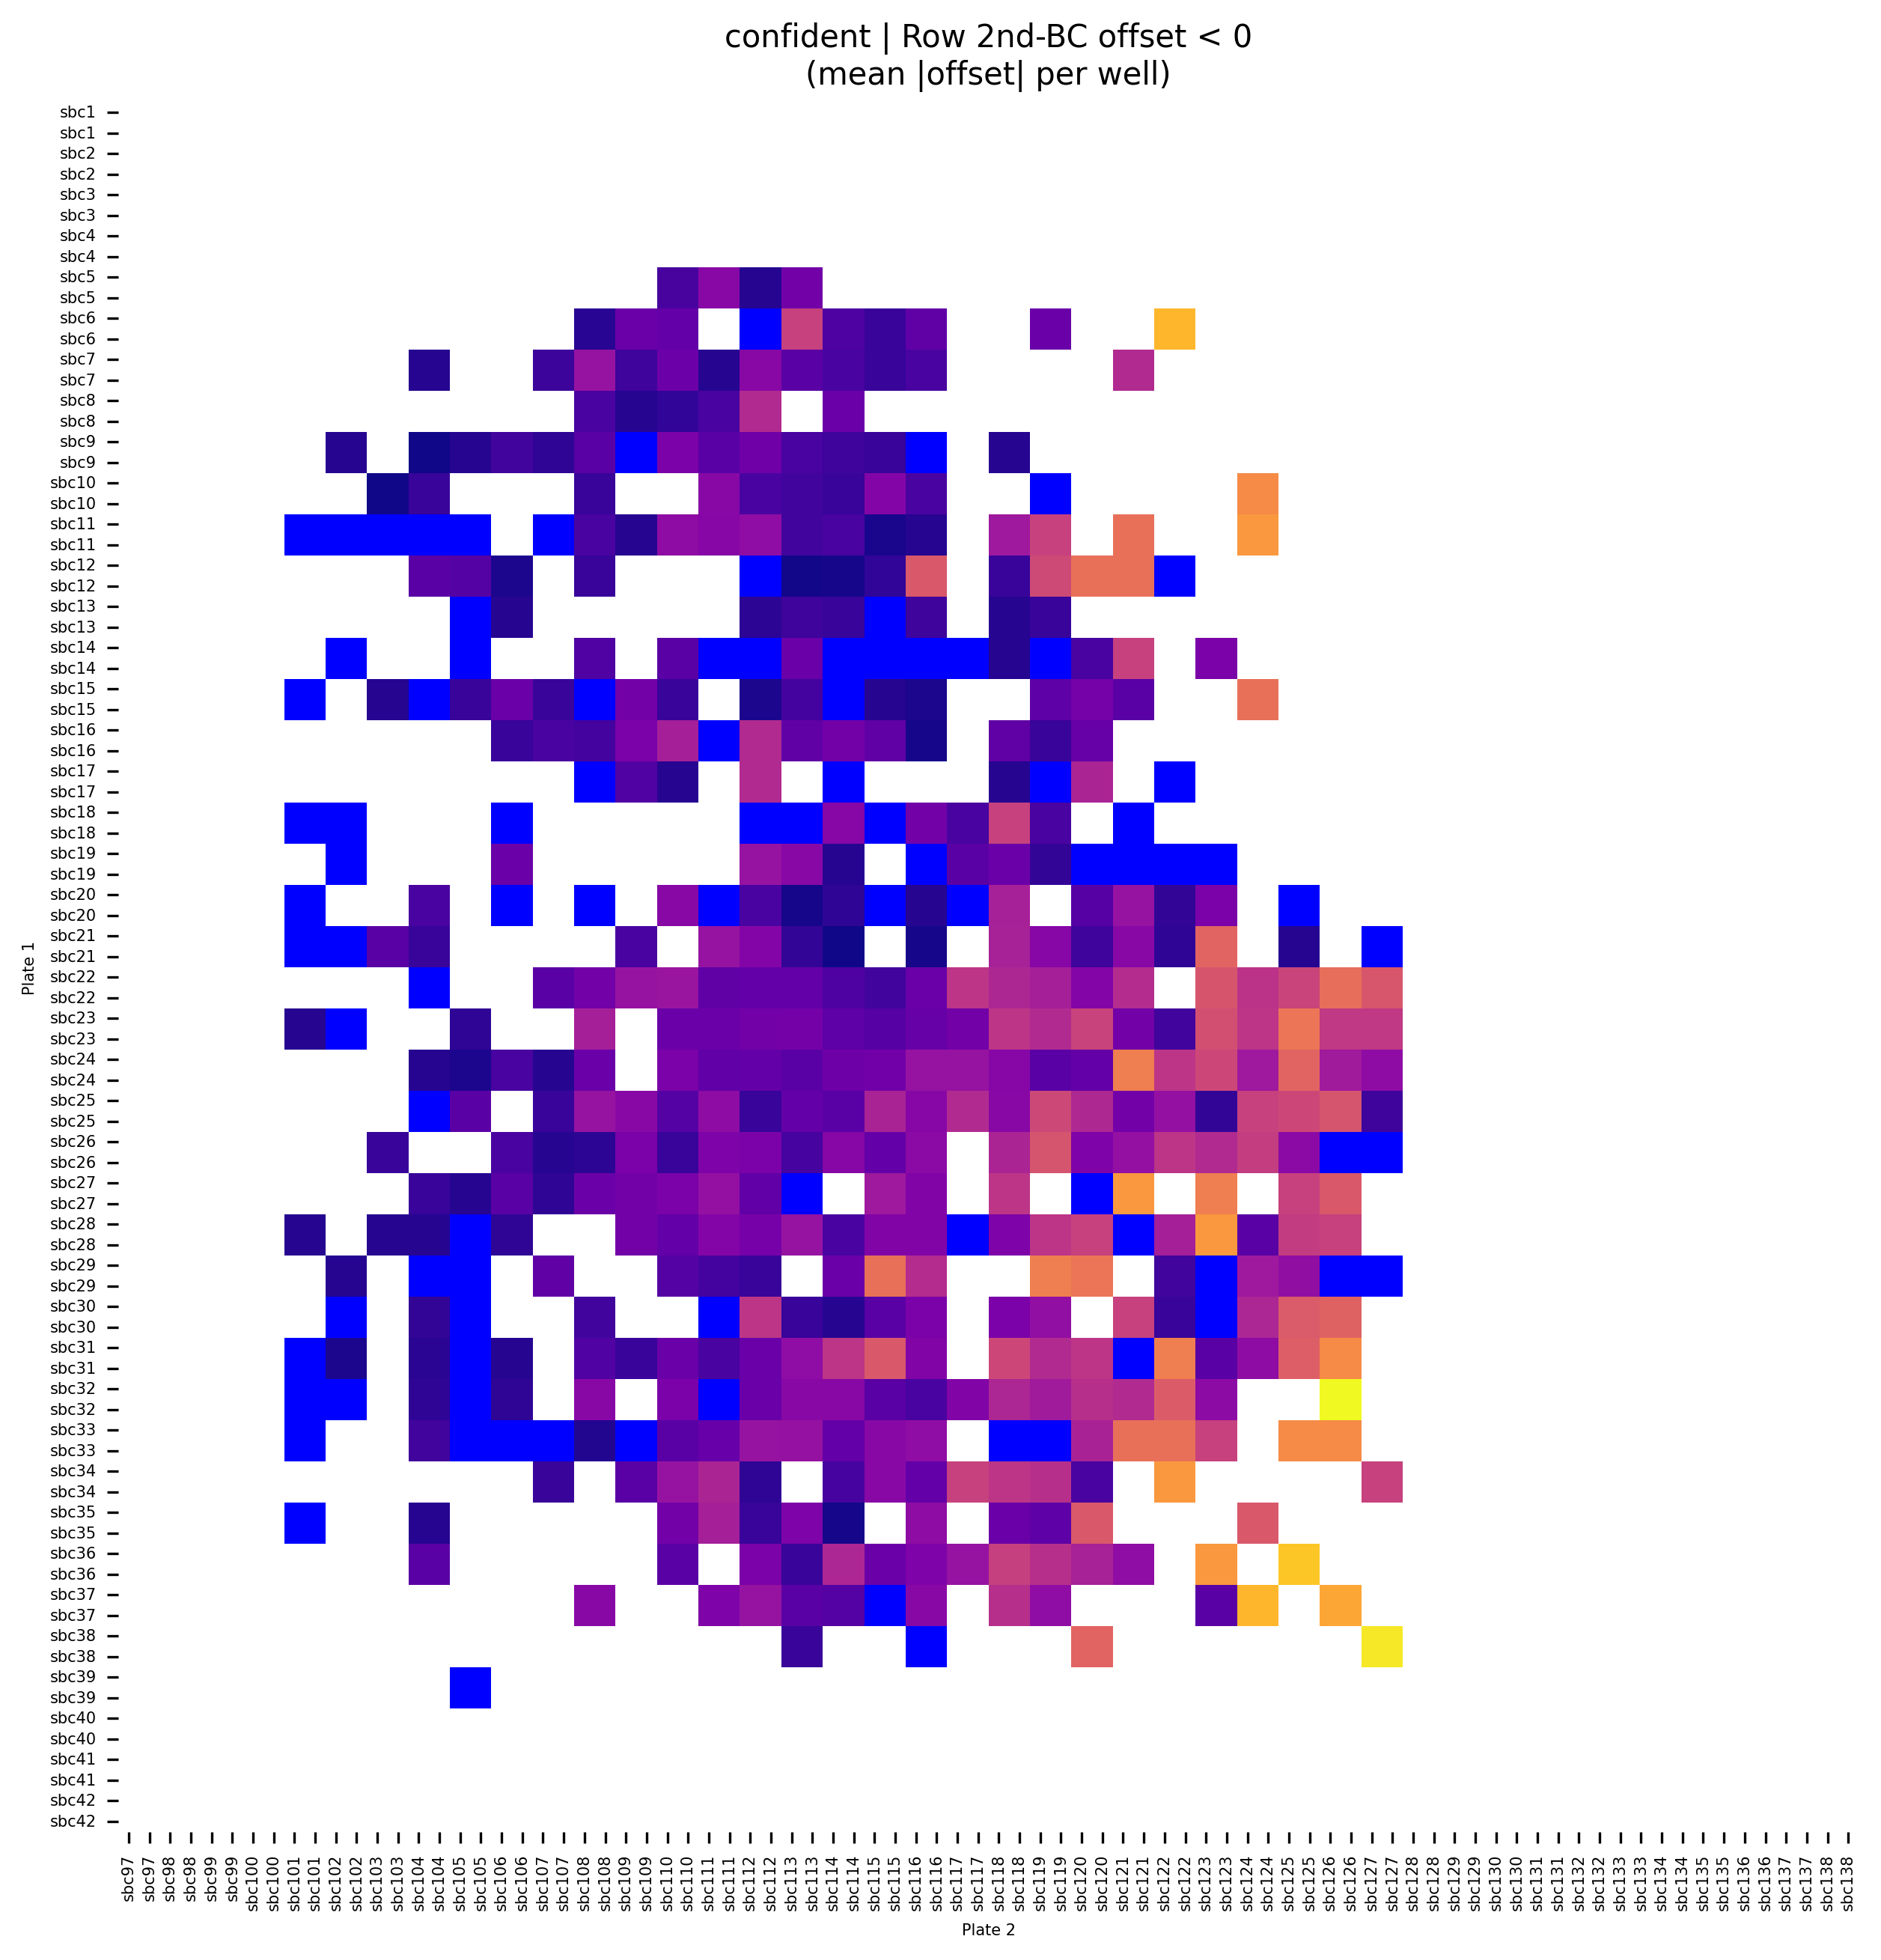

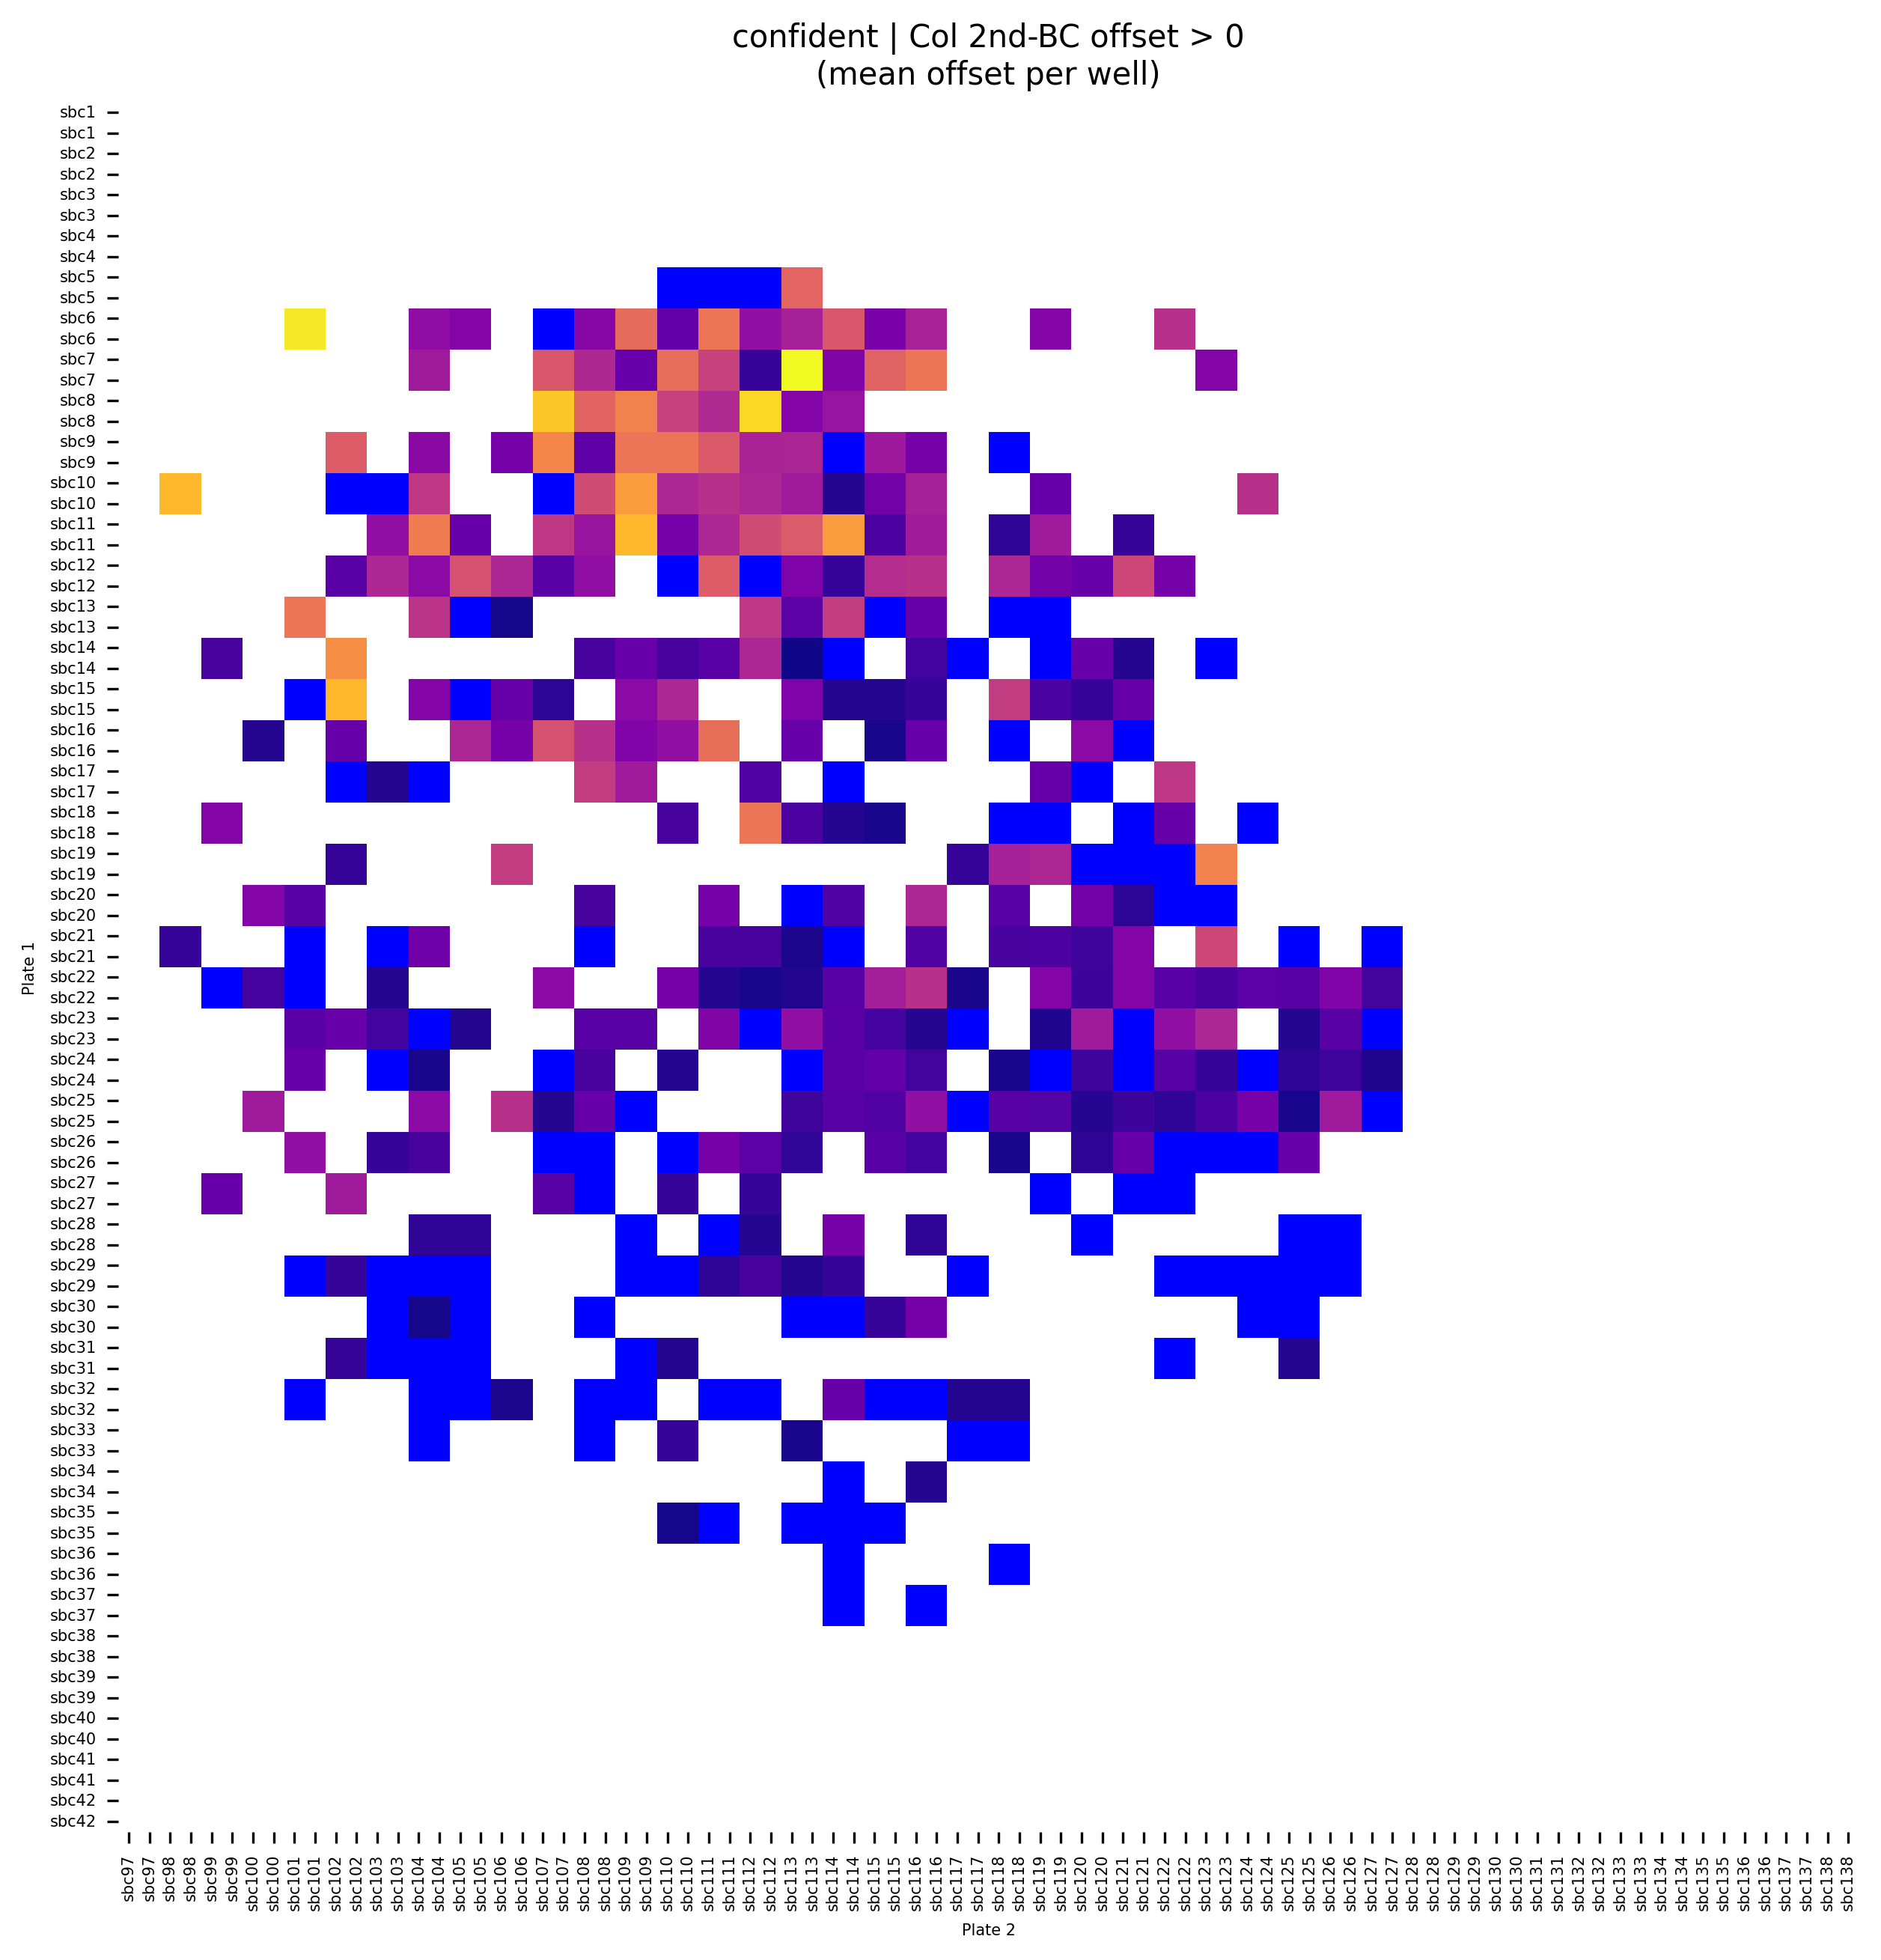

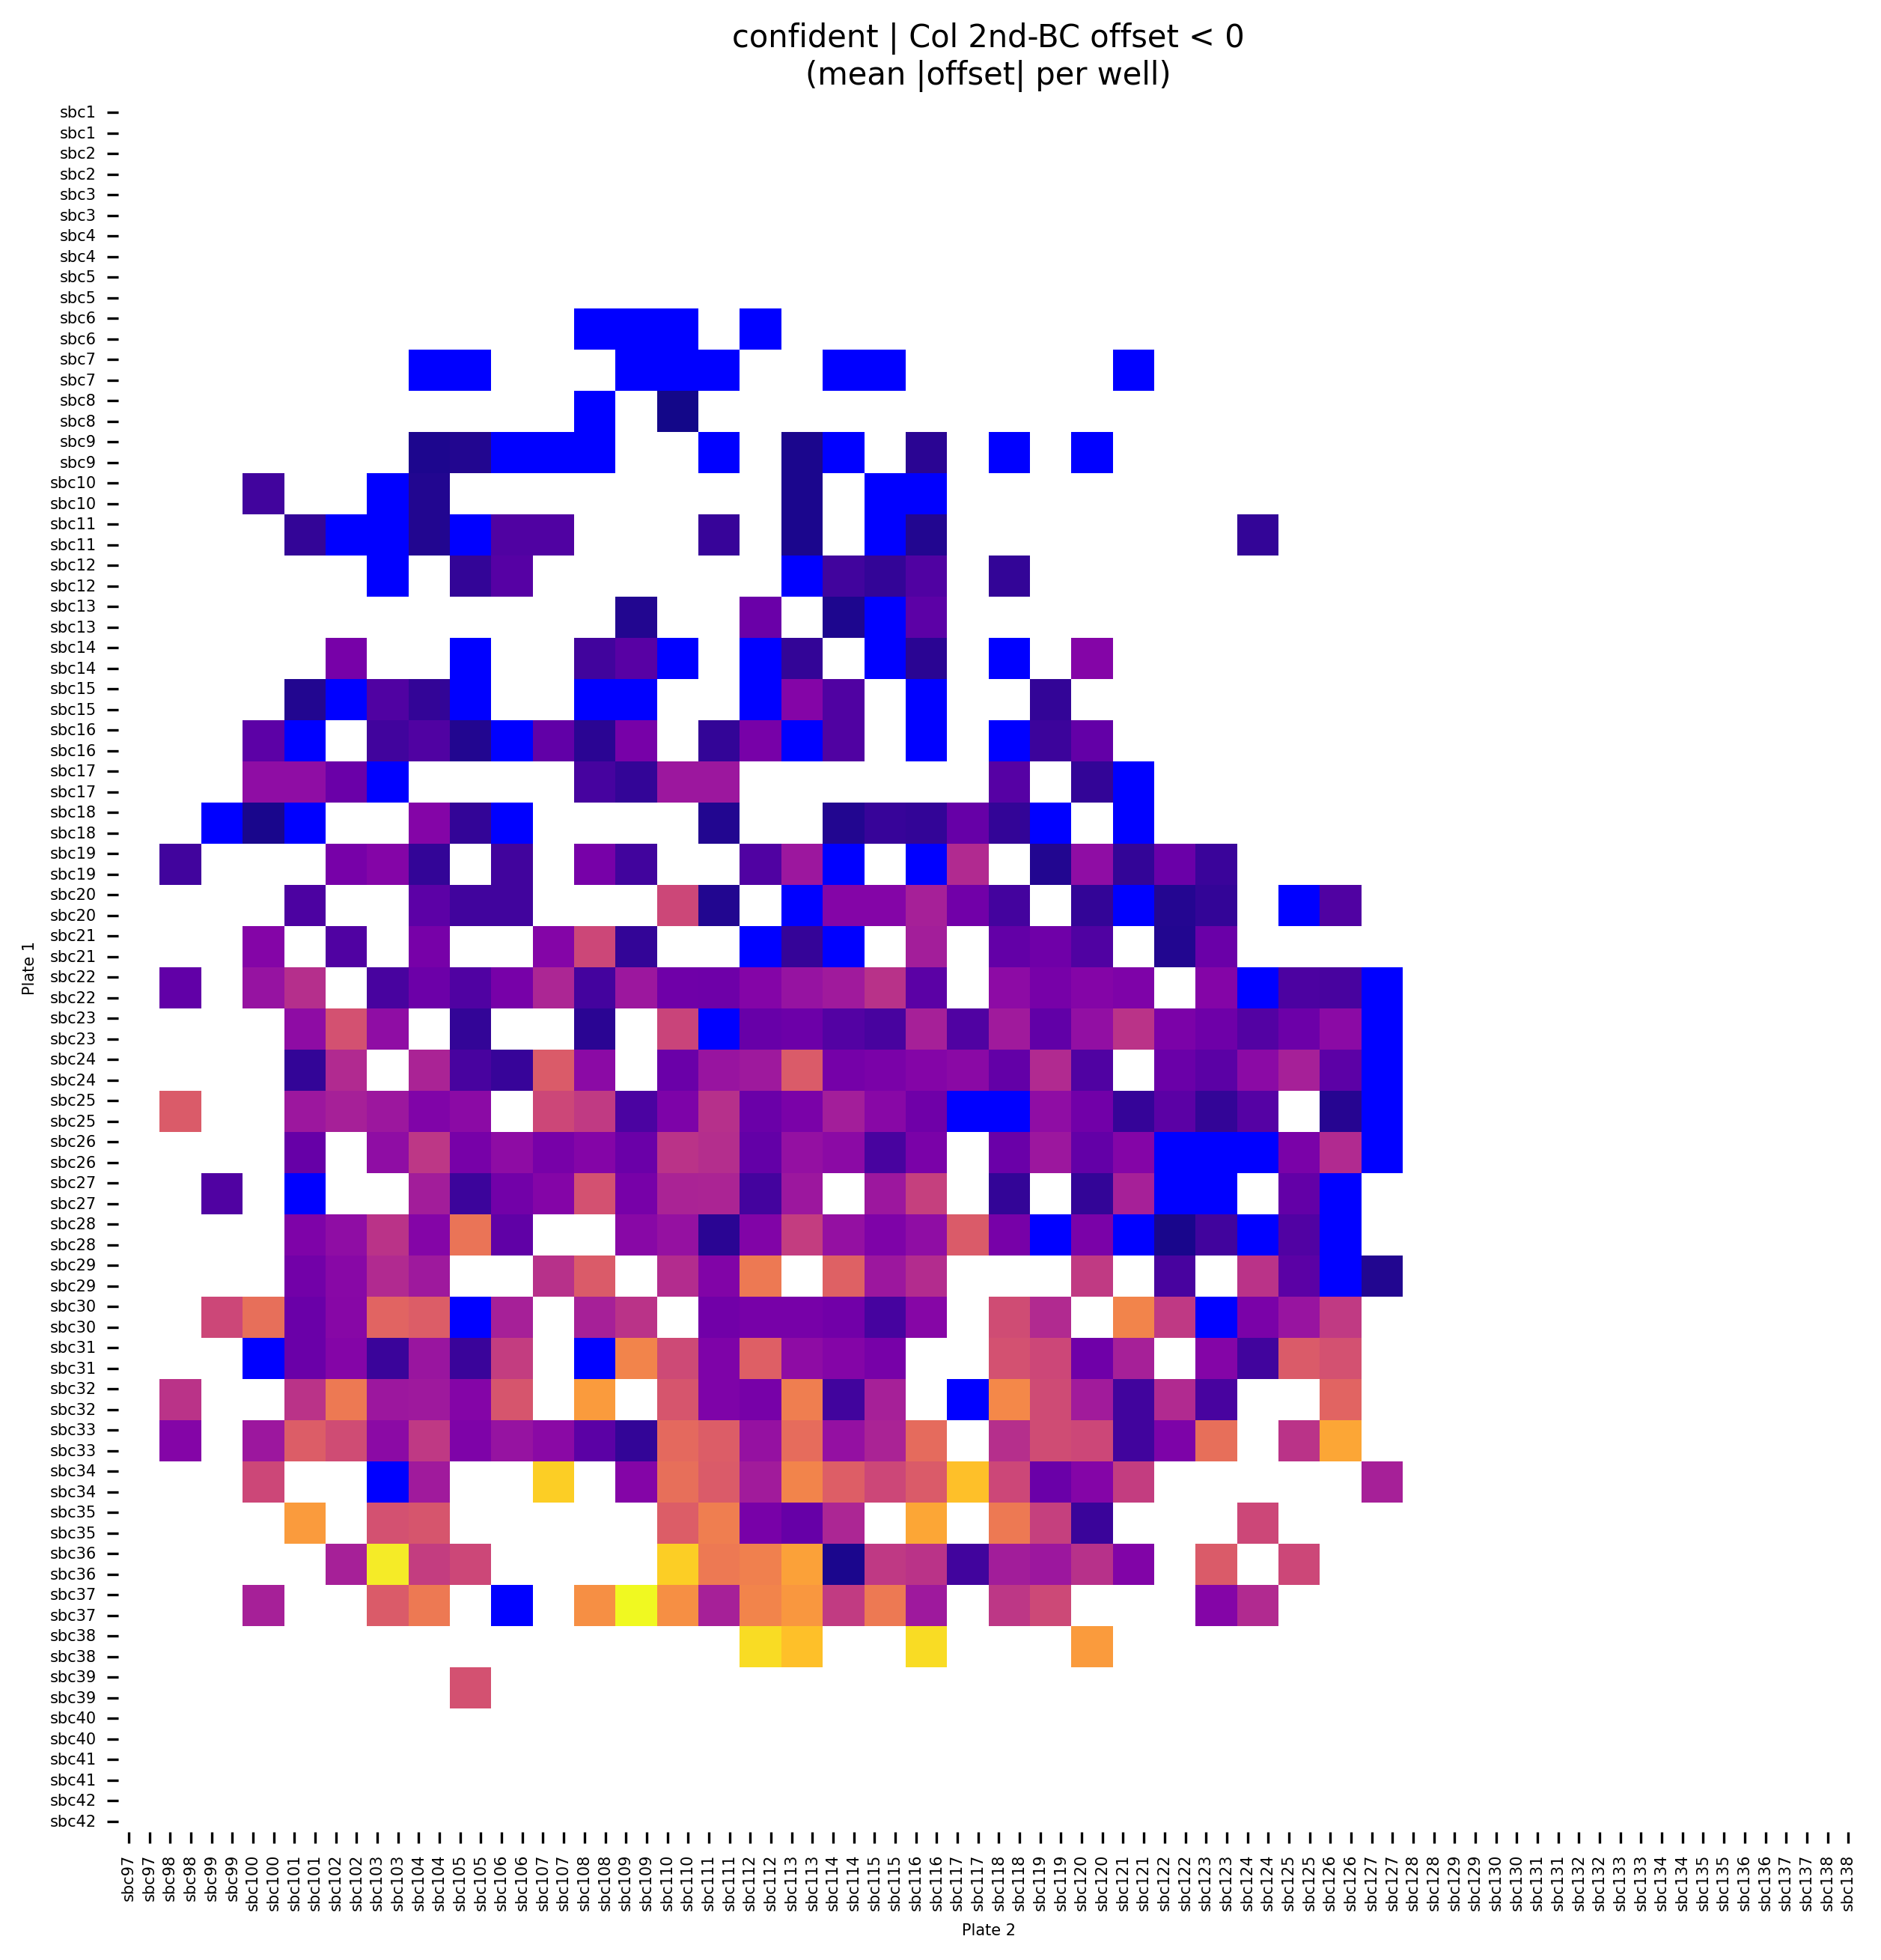

In [111]:
# Second-highest offset BC analysis (confident cells only)
def _second_highest_offset(dist_row):
    """Signed offset of the 2nd-highest ratio BC (0 = top1 BC itself)."""
    s = pd.to_numeric(dist_row, errors='coerce').dropna()
    s = s.drop(0, errors='ignore')
    s = s[s > 0]
    if s.empty:
        return np.nan
    return float(s.idxmax())


def pivot_xy_mean(xy_df, value_col):
    """Same spatial layout as pivot_xy_counts, but mean of value_col per (x, y)."""
    if xy_df.empty:
        return pd.DataFrame(0.0, index=list(df.columns), columns=list(df.index))
    heatmap_data = (
        xy_df.groupby(['x', 'y'])[value_col]
        .mean()
        .reset_index()
        .pivot(index='x', columns='y', values=value_col)
        .fillna(0)
    )
    heatmap_data = heatmap_data.reindex(df.index).T.reindex(df.columns).T.fillna(0).T
    heatmap_data.index, heatmap_data.columns = heatmap_data.columns, heatmap_data.index
    return heatmap_data


def double_matrix_replicate(mat_df):
    """2x2 upsample for heatmap outline (replicate each well value)."""
    a = mat_df.values.astype(float)
    n, m = a.shape
    b = np.zeros((2 * n, 2 * m), dtype=float)
    for i in range(n):
        for j in range(m):
            b[2 * i:2 * i + 2, 2 * j:2 * j + 2] = a[i, j]
    new_rows = [idx for idx in mat_df.index for _ in range(2)]
    new_cols = [col for col in mat_df.columns for _ in range(2)]
    return pd.DataFrame(b, index=new_rows, columns=new_cols)


def plot_offset_spatial_heatmap(pivot_df, title):
    """Match the later spatial count heatmap outline."""
    heatmap_data = double_matrix_replicate(pivot_df)
    heatmap_masked = heatmap_data.copy().astype(float)
    heatmap_masked[heatmap_masked == 0] = np.nan

    plt.figure(figsize=(10, 10), dpi=300)
    sns.heatmap(
        heatmap_masked,
        annot=False,
        fmt='.1f',
        square=False,
        cbar=False,
        cmap=custom_cmap,
        annot_kws={'size': 5},
        xticklabels=1,
        yticklabels=1,
    )
    plt.gca().set_facecolor('white')
    plt.xticks(fontsize=5)
    plt.yticks(fontsize=5)
    plt.xlabel('Plate 2', fontsize=5)
    plt.ylabel('Plate 1', fontsize=5)
    plt.title(title, fontsize=10)
    plt.show()


# Same colormap as the later spatial heatmap section
from matplotlib.colors import LinearSegmentedColormap
_plasma = plt.cm.plasma
_cmap_colors = _plasma(np.linspace(0, 1, 256))
_cmap_colors[0] = [0, 0, 1, 1]
custom_cmap = LinearSegmentedColormap.from_list('plasma_blue', _cmap_colors)

row_2nd_offset = row_dist_ratio_df.apply(_second_highest_offset, axis=1)
col_2nd_offset = col_dist_ratio_df.apply(_second_highest_offset, axis=1)

offset_df = xy_raw[['x', 'y', 'label']].copy()
offset_df['row_2nd_offset'] = row_2nd_offset
offset_df['col_2nd_offset'] = col_2nd_offset
offset_df = offset_df.dropna(subset=['x', 'y'])
offset_df = offset_df[offset_df['label'] == 'confident'].drop(columns='label')

# 1-D average per top1 BC, split by sign
row_pos_avg = offset_df.loc[offset_df['row_2nd_offset'] > 0].groupby('x')['row_2nd_offset'].mean()
row_neg_avg = offset_df.loc[offset_df['row_2nd_offset'] < 0].groupby('x')['row_2nd_offset'].mean()
col_pos_avg = offset_df.loc[offset_df['col_2nd_offset'] > 0].groupby('y')['col_2nd_offset'].mean()
col_neg_avg = offset_df.loc[offset_df['col_2nd_offset'] < 0].groupby('y')['col_2nd_offset'].mean()

# Spatial heatmaps: positive and negative offsets separately
_offset_specs = [
    ('row', 'row_2nd_offset', 'positive', lambda s: s > 0, 'Row 2nd-BC offset > 0'),
    ('row', 'row_2nd_offset', 'negative', lambda s: s < 0, 'Row 2nd-BC offset < 0'),
    ('col', 'col_2nd_offset', 'positive', lambda s: s > 0, 'Col 2nd-BC offset > 0'),
    ('col', 'col_2nd_offset', 'negative', lambda s: s < 0, 'Col 2nd-BC offset < 0'),
]

for _axis, _col, _sign, _mask_fn, _title in _offset_specs:
    sub = offset_df[_mask_fn(offset_df[_col])].copy()
    if sub.empty:
        print(f'Skipping {_title}: no confident cells')
        continue
    if _sign == 'negative':
        sub[_col] = sub[_col].abs()
    pivot = pivot_xy_mean(sub, _col)
    lbl = '(mean |offset| per well)' if _sign == 'negative' else '(mean offset per well)'
    plot_offset_spatial_heatmap(pivot, f'confident | {_title}\n{lbl}')

# 1-D bar summaries
# fig, axes = plt.subplots(2, 2, figsize=(16, 10), dpi=120)
# _bar_specs = [
#     (axes[0, 0], row_pos_avg, 'Row positive offset by top1 row BC'),
#     (axes[0, 1], row_neg_avg.abs(), 'Row negative offset by top1 row BC (|mean|)'),
#     (axes[1, 0], col_pos_avg, 'Col positive offset by top1 col BC'),
#     (axes[1, 1], col_neg_avg.abs(), 'Col negative offset by top1 col BC (|mean|)'),
# ]
# for ax, avg_s, title in _bar_specs:
#     if avg_s.empty:
#         ax.set_title(title + '\n(no data)')
#         ax.axis('off')
#         continue
#     ax.bar(range(len(avg_s)), avg_s.values, color='steelblue', edgecolor='none')
#     ax.set_xticks(range(len(avg_s)))
#     ax.set_xticklabels(avg_s.index, rotation=90, fontsize=6)
#     ax.set_title(title, fontsize=10)
#     ax.set_ylabel('Mean offset', fontsize=8)
#     ax.grid(True, alpha=0.3, axis='y')

# plt.suptitle('2nd-highest BC offset - confident cells, split by sign', fontsize=12)
# plt.tight_layout()
# plt.show()


In [ ]:
# Mixture Adjacency Score (MAS) per spatial well
#
# Ideal: each well has exactly one row BC + one col BC.
# MAS measures how much leakage from immediately adjacent wells is present,
# normalised by the number of real neighbours so edge/corner wells are
# comparable to interior wells.
#
# For well at grid position (row_i, col_j):
#   n_row_nbrs = neighbours in the row direction  (1 at edge, 2 interior)
#   n_col_nbrs = neighbours in the col direction  (1 at edge, 2 interior)
#
# For the confident cells assigned to that well:
#   frac_imm_row = fraction whose |row_2nd_offset| == 1
#   frac_imm_col = fraction whose |col_2nd_offset| == 1
#
# MAS = frac_imm_row / n_row_nbrs  +  frac_imm_col / n_col_nbrs
# Range 0–2; higher => more per-neighbour leakage at that well.

row_idx = {bc: i for i, bc in enumerate(rows)}
col_idx = {bc: j for j, bc in enumerate(cols)}
R, C = len(rows), len(cols)

def _n_neighbours(idx, total):
    return int(idx > 0) + int(idx < total - 1)

def _position_type(ri, ci):
    nr = _n_neighbours(ri, R)
    nc = _n_neighbours(ci, C)
    if nr == 1 and nc == 1:
        return 'corner'
    if nr == 1 or nc == 1:
        return 'edge'
    return 'interior'

# offset_df already filtered to confident cells, has x, y, row_2nd_offset, col_2nd_offset
mas_rows = []
for (r_bc, c_bc), grp in offset_df.groupby(['x', 'y']):
    ri = row_idx.get(r_bc)
    ci = col_idx.get(c_bc)
    if ri is None or ci is None:
        continue
    n_row_nbrs = _n_neighbours(ri, R)
    n_col_nbrs = _n_neighbours(ci, C)

    row_off = grp['row_2nd_offset'].dropna()
    col_off = grp['col_2nd_offset'].dropna()

    frac_imm_row = (row_off.abs() == 1).mean() if len(row_off) else np.nan
    frac_imm_col = (col_off.abs() == 1).mean() if len(col_off) else np.nan

    if np.isnan(frac_imm_row) or np.isnan(frac_imm_col):
        mas = np.nan
    else:
        mas = frac_imm_row / n_row_nbrs + frac_imm_col / n_col_nbrs

    mas_rows.append({
        'x': r_bc, 'y': c_bc,
        'row_i': ri, 'col_j': ci,
        'n_cells': len(grp),
        'n_row_nbrs': n_row_nbrs,
        'n_col_nbrs': n_col_nbrs,
        'frac_imm_row': frac_imm_row,
        'frac_imm_col': frac_imm_col,
        'mas': mas,
        'position_type': _position_type(ri, ci),
    })

mas_df = pd.DataFrame(mas_rows)

# ── Spatial heatmap of MAS ───────────────────────────────────────────────────
mas_pivot = (
    mas_df.pivot(index='x', columns='y', values='mas')
    .reindex(index=df.index).T.reindex(df.columns).T.fillna(0).T
)
mas_pivot.index, mas_pivot.columns = mas_pivot.columns, mas_pivot.index

heatmap_data = double_matrix_replicate(mas_pivot.fillna(0))
heatmap_masked = heatmap_data.copy().astype(float)
heatmap_masked[heatmap_masked == 0] = np.nan

plt.figure(figsize=(10, 10), dpi=300)
sns.heatmap(
    heatmap_masked,
    annot=False,
    fmt='.2f',
    square=False,
    cbar=False,
    cmap=custom_cmap,
    annot_kws={'size': 5},
    xticklabels=1,
    yticklabels=1,
)
plt.gca().set_facecolor('white')
plt.xticks(fontsize=5)
plt.yticks(fontsize=5)
plt.xlabel('Plate 2', fontsize=5)
plt.ylabel('Plate 1', fontsize=5)
plt.title('Mixture Adjacency Score (MAS) per well\n'
          'confident cells | edge/corner normalised', fontsize=10)
plt.show()

# ── Distribution by position type ───────────────────────────────────────────
order = ['corner', 'edge', 'interior']
palette = {'corner': '#e07b39', 'edge': '#5b8db8', 'interior': '#6ab187'}

fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=120)

for ax, metric, ylabel, title in [
    (axes[0], 'mas',
     'MAS (0-2)',
     'Mixture Adjacency Score by position type'),
    (axes[1], 'frac_imm_row',
     'Fraction cells with |row_offset|=1',
     'Immediate row-neighbour leakage fraction'),
]:
    sub = mas_df.dropna(subset=[metric])
    for pos_type in order:
        vals = sub.loc[sub['position_type'] == pos_type, metric]
        ax.violinplot([vals], positions=[order.index(pos_type)],
                      showmedians=True, widths=0.6)
    ax.set_xticks(range(len(order)))
    ax.set_xticklabels(order, fontsize=9)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_title(title, fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('MAS — confident cells, edge/corner-normalised', fontsize=12)
plt.tight_layout()
plt.show()

# ── Summary table ───────────────────────────────────────────────────────────
display(
    mas_df.groupby('position_type')[['frac_imm_row', 'frac_imm_col', 'mas']]
    .agg(['mean', 'median', 'std'])
    .round(4)
    .reindex(order)
)


In [ ]:
# Fraction of cells per offset-distance bin, per spatial well
# Row and col offsets evaluated separately.
# offset_df already contains row_2nd_offset / col_2nd_offset for confident cells.

cutoffs = [0, 3, 6, 9, 12, 15]  # bin edges: [0,3), [3,6), [6,9), ...

def _bin_label(lo, hi):
    return f'|offset| [{lo},{hi})'

def pivot_frac(xy_df, value_col):
    """Pivot mean of value_col over (x, y), matching the spatial grid layout."""
    if xy_df.empty:
        return pd.DataFrame(np.nan, index=list(df.columns), columns=list(df.index))
    hm = (
        xy_df.groupby(['x', 'y'])[value_col]
        .mean()
        .reset_index()
        .pivot(index='x', columns='y', values=value_col)
    )
    hm = hm.reindex(df.index).T.reindex(df.columns).T.fillna(np.nan).T
    hm.index, hm.columns = hm.columns, hm.index
    return hm

# Pre-compute absolute offsets once
_od = offset_df.copy()
_od['row_abs'] = _od['row_2nd_offset'].abs()
_od['col_abs'] = _od['col_2nd_offset'].abs()

# Build one indicator column per bin per axis
bin_labels = []
for lo, hi in zip(cutoffs[:-1], cutoffs[1:]):
    lbl = _bin_label(lo, hi)
    bin_labels.append(lbl)
    _od[f'row_{lbl}'] = ((_od['row_abs'] >= lo) & (_od['row_abs'] < hi)).astype(float)
    _od[f'col_{lbl}'] = ((_od['col_abs'] >= lo) & (_od['col_abs'] < hi)).astype(float)

# Also add a final open-ended bin: >= last cutoff
lo_last = cutoffs[-1]
lbl_last = f'|offset| [{lo_last},inf)'
bin_labels.append(lbl_last)
_od[f'row_{lbl_last}'] = (_od['row_abs'] >= lo_last).astype(float)
_od[f'col_{lbl_last}'] = (_od['col_abs'] >= lo_last).astype(float)

n_bins = len(bin_labels)


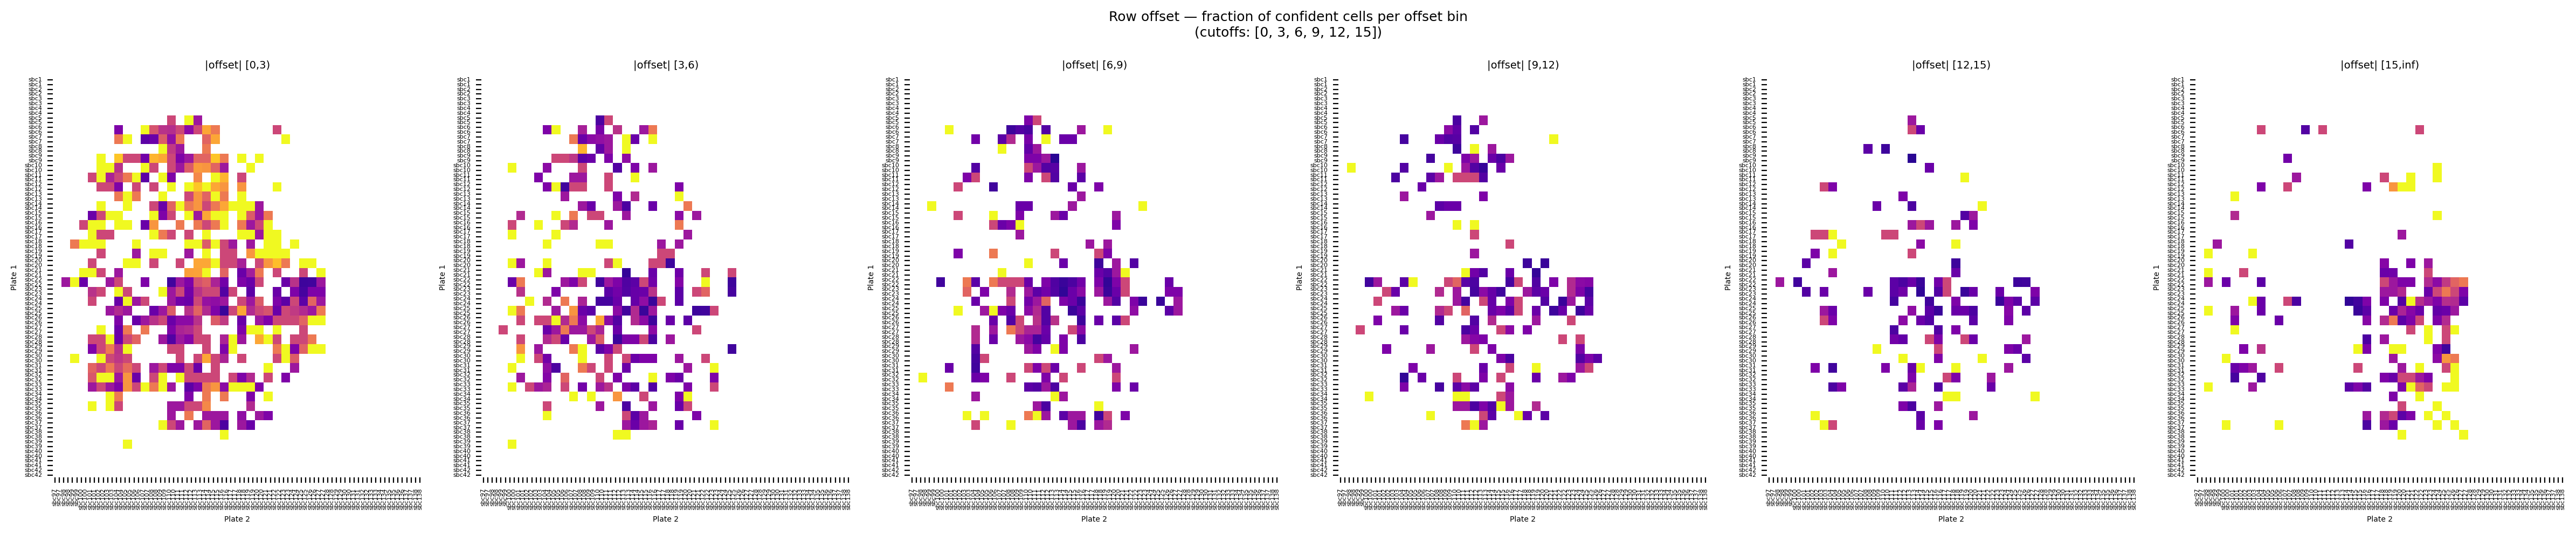

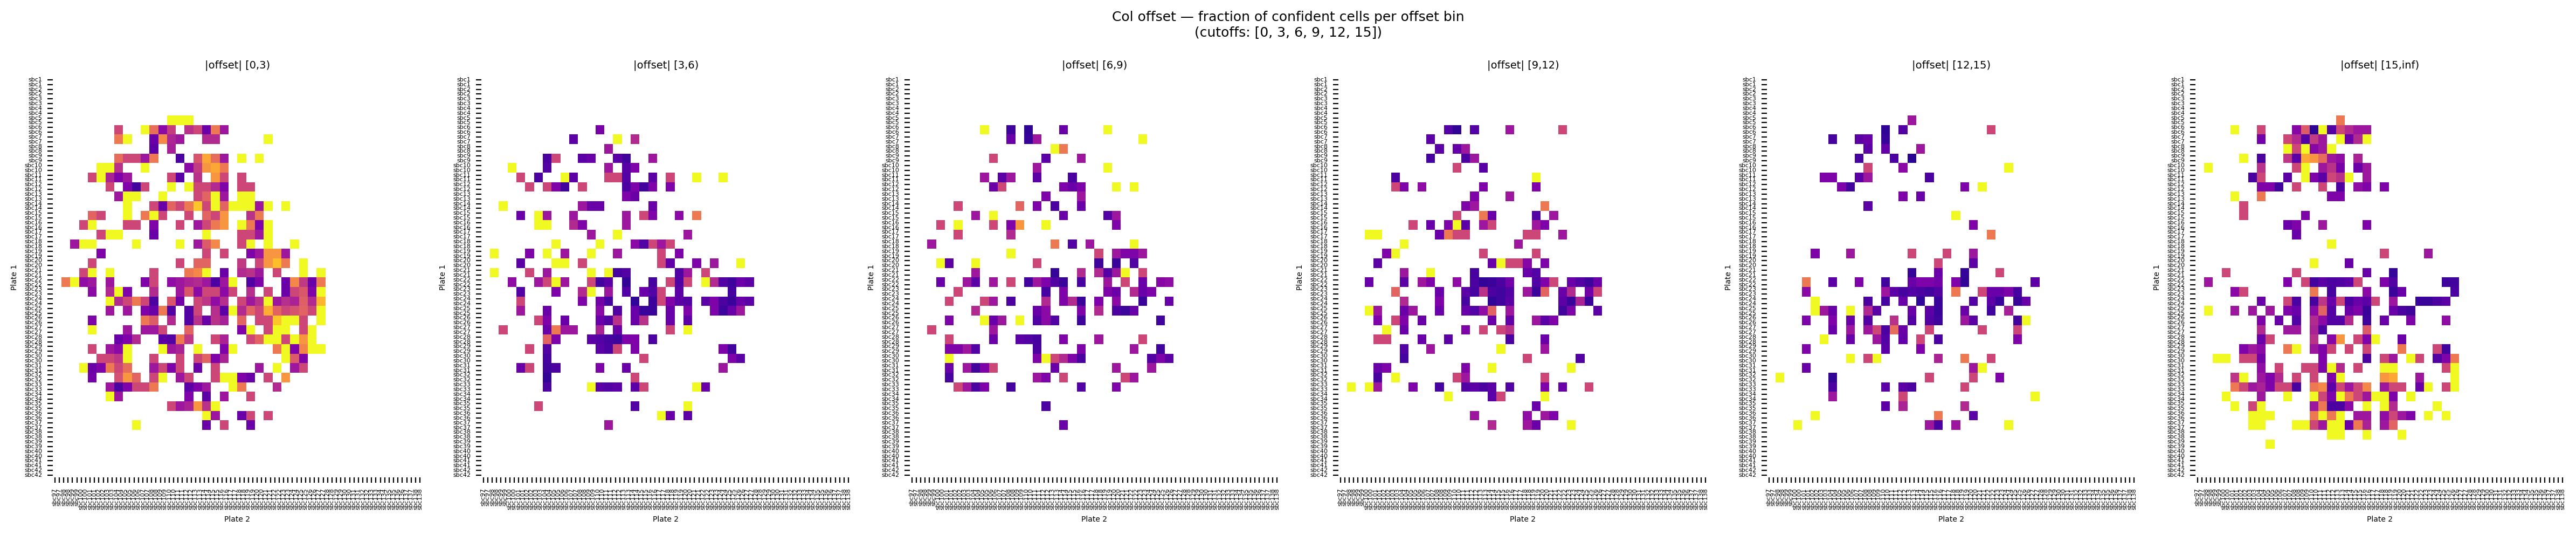

In [116]:

# ── Plot: one row of heatmaps per bin, columns = [row axis, col axis] ────────
for axis_name, prefix in [('Row offset', 'row'), ('Col offset', 'col')]:
    fig, axes_grid = plt.subplots(
        1, n_bins,
        figsize=(4 * n_bins, 5),
        dpi=200,
    )
    if n_bins == 1:
        axes_grid = [axes_grid]

    for ax, lbl in zip(axes_grid, bin_labels):
        col_key = f'{prefix}_{lbl}'
        piv = pivot_frac(_od, col_key)

        hm = double_matrix_replicate(piv.fillna(0))
        hm_masked = hm.copy().astype(float)
        hm_masked[hm_masked == 0] = np.nan

        sns.heatmap(
            hm_masked,
            ax=ax,
            annot=False,
            square=False,
            cbar=False,
            cmap=custom_cmap,
            vmin=0,
            vmax=1,
            xticklabels=1,
            yticklabels=1,
        )
        ax.set_facecolor('white')
        ax.tick_params(axis='x', labelsize=4, rotation=90)
        ax.tick_params(axis='y', labelsize=4, rotation=0)
        ax.set_xlabel('Plate 2', fontsize=5)
        ax.set_ylabel('Plate 1', fontsize=5)
        ax.set_title(lbl, fontsize=7)

    plt.suptitle(
        f'{axis_name} — fraction of confident cells per offset bin\n'
        f'(cutoffs: {cutoffs})',
        fontsize=9,
    )
    plt.tight_layout()
    plt.show()


In [ ]:
aa

NameError: name 'aa' is not defined

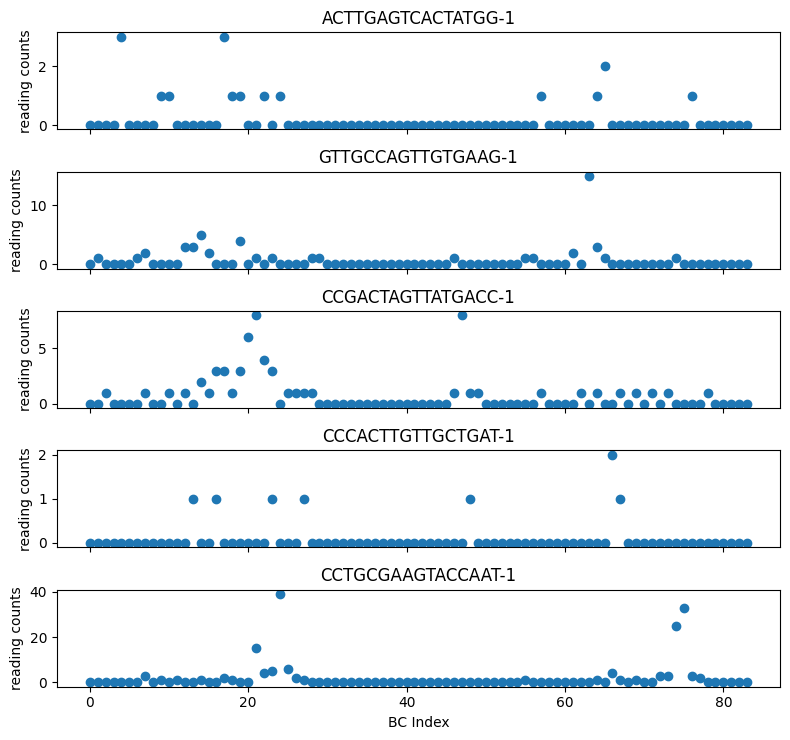

In [ ]:
import matplotlib.pyplot as plt
k = int(CONFIG['nonconfident_sample_k'])  # number of rows to sample
confident_rows = xy_raw[xy_raw['label'] == 'non-confident']
sampled = prot_DF_filtered.loc[confident_rows.index].sample(n=k, replace=False)

fig, axes = plt.subplots(
    nrows=k,
    ncols=1,
    figsize=(8, 1.5 * k),  # reduced height per subplot
    sharex=True
)

# If k == 1, axes is not a list
if k == 1:
    axes = [axes]

for ax, (idx, row) in zip(axes, sampled.iterrows()):
    ax.scatter(np.arange(len(row)), row.values)
    # ax.set_ylabel(str(idx), rotation=45, labelpad=30, va="center")
    ax.set_ylabel("reading counts")
    ax.set_title(str(idx))

axes[-1].set_xlabel("BC Index")
axes[-1].set_xlabel("BC Index")
plt.tight_layout()
plt.show()

# UMI QC

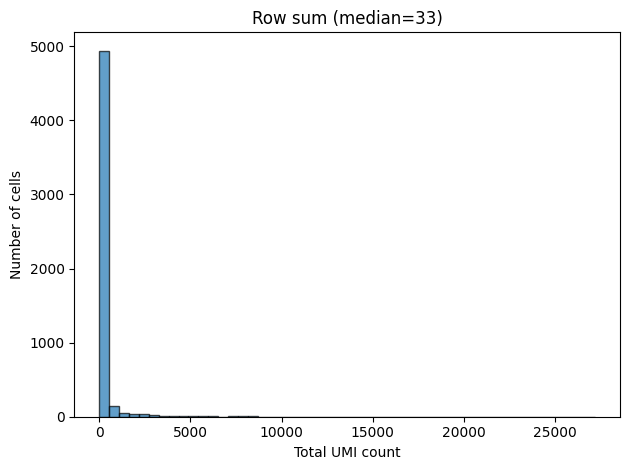

In [ ]:
nonzero_per_row = (prot_DF_filtered != 0).sum(axis=1)
sum_per_row = prot_DF_filtered.sum(axis=1)

plt.hist(sum_per_row, bins=50, edgecolor="black", alpha=0.7)
plt.xlabel("Total UMI count")
plt.ylabel("Number of cells")
plt.title(f"Row sum (median={sum_per_row.median():.0f})")

plt.tight_layout()
plt.show()

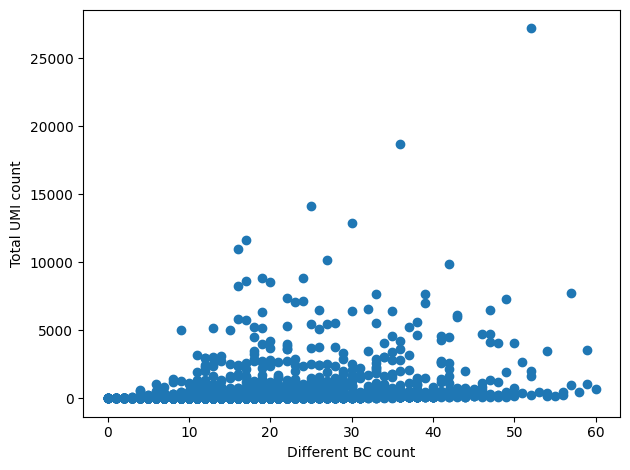

In [ ]:
plt.scatter(nonzero_per_row, sum_per_row)
plt.xlabel("Different BC count")
plt.ylabel("Total UMI count")
plt.tight_layout()
plt.show()

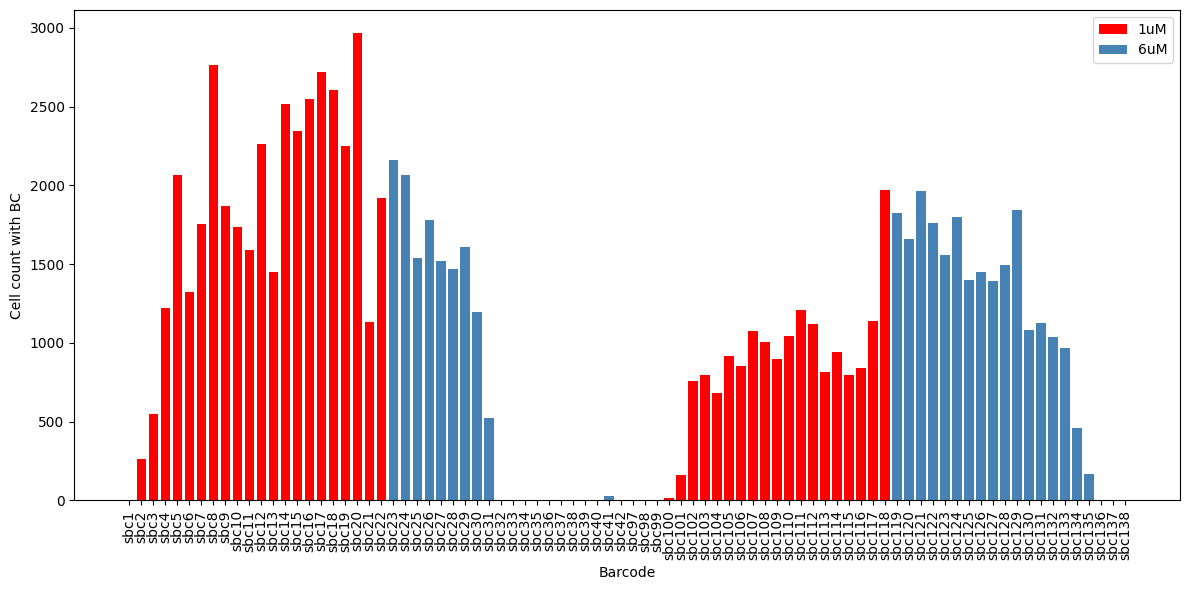

In [ ]:
SBC_DF_binary = prot_DF_filtered.applymap(lambda x: 1 if x > 0 else 0)
BC_appearance = SBC_DF_binary.sum(axis=0)

from matplotlib.patches import Patch
# Define which indices get red (from CONFIG['red_ranges']).
red_set = set()
for _start, _end in CONFIG['red_ranges']:
    red_set.update(f"{_bc_prefix}{i}" for i in range(_start, _end))

colors = ['red' if idx in red_set else 'steelblue' for idx in BC_appearance.index]

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(BC_appearance.index, BC_appearance.values, color=colors)
ax.set_xlabel('Barcode')
ax.set_ylabel('Cell count with BC')

legend_elements = [
    Patch(facecolor='red',      label='1uM'),
    Patch(facecolor='steelblue', label='6uM'),
]
ax.legend(handles=legend_elements)

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

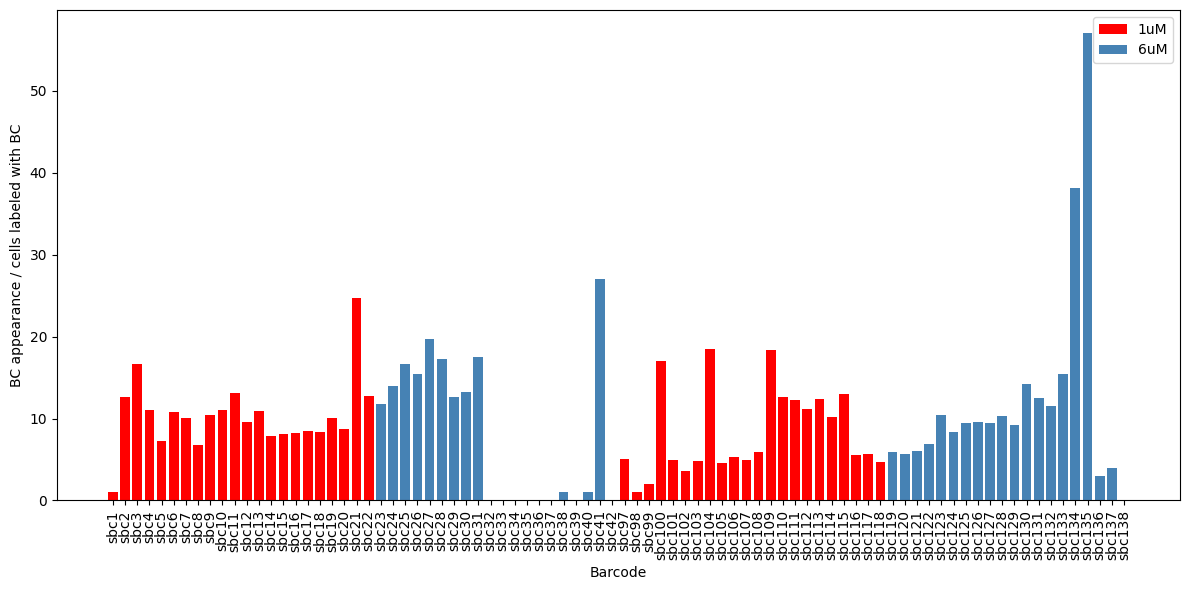

In [ ]:
SBC_DF_binary = prot_DF_filtered.applymap(lambda x: 1 if x > 0 else 0)
BC_appearance = SBC_DF_binary.sum(axis=0)

labeled_counts = pd.concat([
    xy_raw["x"].value_counts(),
    xy_raw["y"].value_counts()
])
BC_appearance_norm = BC_appearance / labeled_counts.reindex(BC_appearance.index).fillna(1)

from matplotlib.patches import Patch
red_set = set()
for _start, _end in CONFIG['red_ranges']:
    red_set.update(f"{_bc_prefix}{i}" for i in range(_start, _end))

colors = ['red' if idx in red_set else 'steelblue' for idx in BC_appearance_norm.index]

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(BC_appearance_norm.index, BC_appearance_norm.values, color=colors)
ax.set_xlabel('Barcode')
ax.set_ylabel('BC appearance / cells labeled with BC')

legend_elements = [
    Patch(facecolor='red',      label='1uM'),
    Patch(facecolor='steelblue', label='6uM'),
]
ax.legend(handles=legend_elements)

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

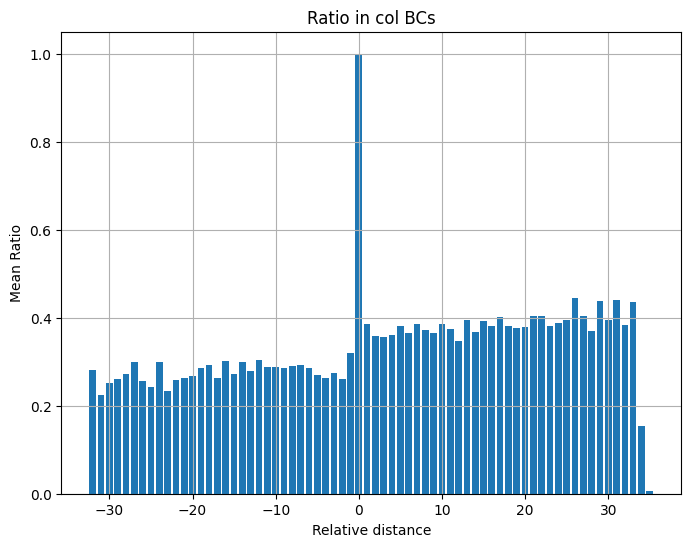

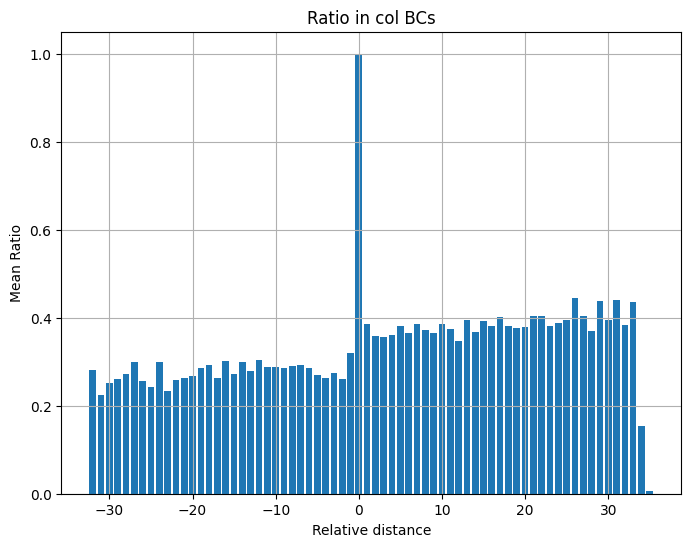

In [ ]:
k_top = int(CONFIG['top_k'])

top_k_bcs = BC_appearance.nlargest(k_top).index
# top_k_bcs = BC_appearance.nsmallest(k_top).index

# row_center_series = []
# col_center_series = []

# for center_bc in top_k_bcs:
#     if center_bc in rows:
#         order = rows
#     elif center_bc in cols:
#         order = cols
#     else:
#         continue
#     i0 = order.index(center_bc)
#     center_val = float(BC_appearance[center_bc])
#     dr = {}
#     for j, bc in enumerate(order):
#         val = BC_appearance.get(bc, 0)
#         if val == 0:
#             continue
#         dr[j - i0] = float(val) / center_val
#     s = pd.Series(dr, dtype=np.float64, name=center_bc)
#     if center_bc in rows:
#         row_center_series.append(s)
#     else:
#         col_center_series.append(s)

# row_bc_dist_ratio_df = pd.DataFrame(row_center_series)
# row_bc_dist_ratio_df = row_bc_dist_ratio_df[sorted(row_bc_dist_ratio_df.columns)].fillna(0)
# a = col_dist_ratio_df.mean(axis=0)
# plt.figure(figsize=(8,6))
# plt.bar(a.index, a.values, width=0.8)
# plt.xlabel("Relative distance")
# plt.ylabel("Mean Ratio")
# plt.title("Ratio in col BCs")
# plt.grid(True)
# plt.show()

# col_bc_dist_ratio_df = pd.DataFrame(col_center_series)
# col_bc_dist_ratio_df = col_bc_dist_ratio_df[sorted(col_bc_dist_ratio_df.columns)].fillna(0)
# b = col_dist_ratio_df.mean(axis=0)
# plt.figure(figsize=(8,6))
# plt.bar(b.index, b.values, width=0.8)
# plt.xlabel("Relative distance")
# plt.ylabel("Mean Ratio")
# plt.title("Ratio in col BCs")
# plt.grid(True)
# plt.show()

In [ ]:
mask = prot_DF_filtered[top_k_bcs].any(axis=1)
nonzero_topk = nonzero_per_row[mask]
sum_topk = sum_per_row[mask]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(nonzero_topk, bins=50, edgecolor="black", alpha=0.7)
axes[0].set_xlabel("Number of nonzero columns")
axes[0].set_ylabel("Number of cells")
axes[0].set_title(f"Nonzero BCs per cell — top-{k_top} BC cells (n={mask.sum()}, median={int(nonzero_topk.median())})")

axes[1].hist(sum_topk, bins=50, edgecolor="black", alpha=0.7)
axes[1].set_xlabel("Total UMI count")
axes[1].set_ylabel("Number of cells")
axes[1].set_title(f"Row sum — top-{k_top} BC cells (n={mask.sum()}, median={sum_topk.median():.0f})")

NameError: name 'top_k_bcs' is not defined

Text(0, 0.5, 'Number of cells')

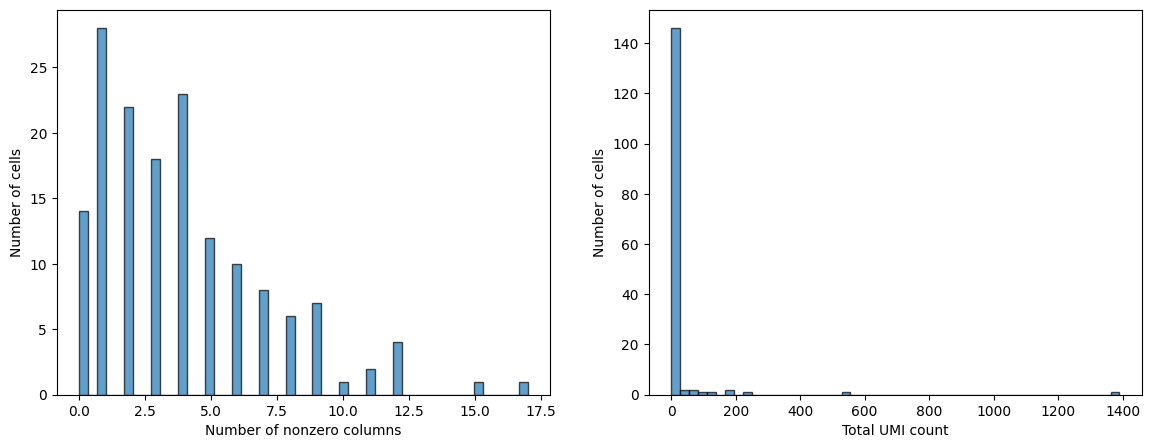

In [ ]:
mask = prot_DF_filtered[top_k_bcs].any(axis=1)
nonzero_topk = nonzero_per_row[~mask]
sum_topk = sum_per_row[~mask]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(nonzero_topk, bins=50, edgecolor="black", alpha=0.7)
axes[0].set_xlabel("Number of nonzero columns")
axes[0].set_ylabel("Number of cells")

axes[1].hist(sum_topk, bins=50, edgecolor="black", alpha=0.7)
axes[1].set_xlabel("Total UMI count")
axes[1].set_ylabel("Number of cells")


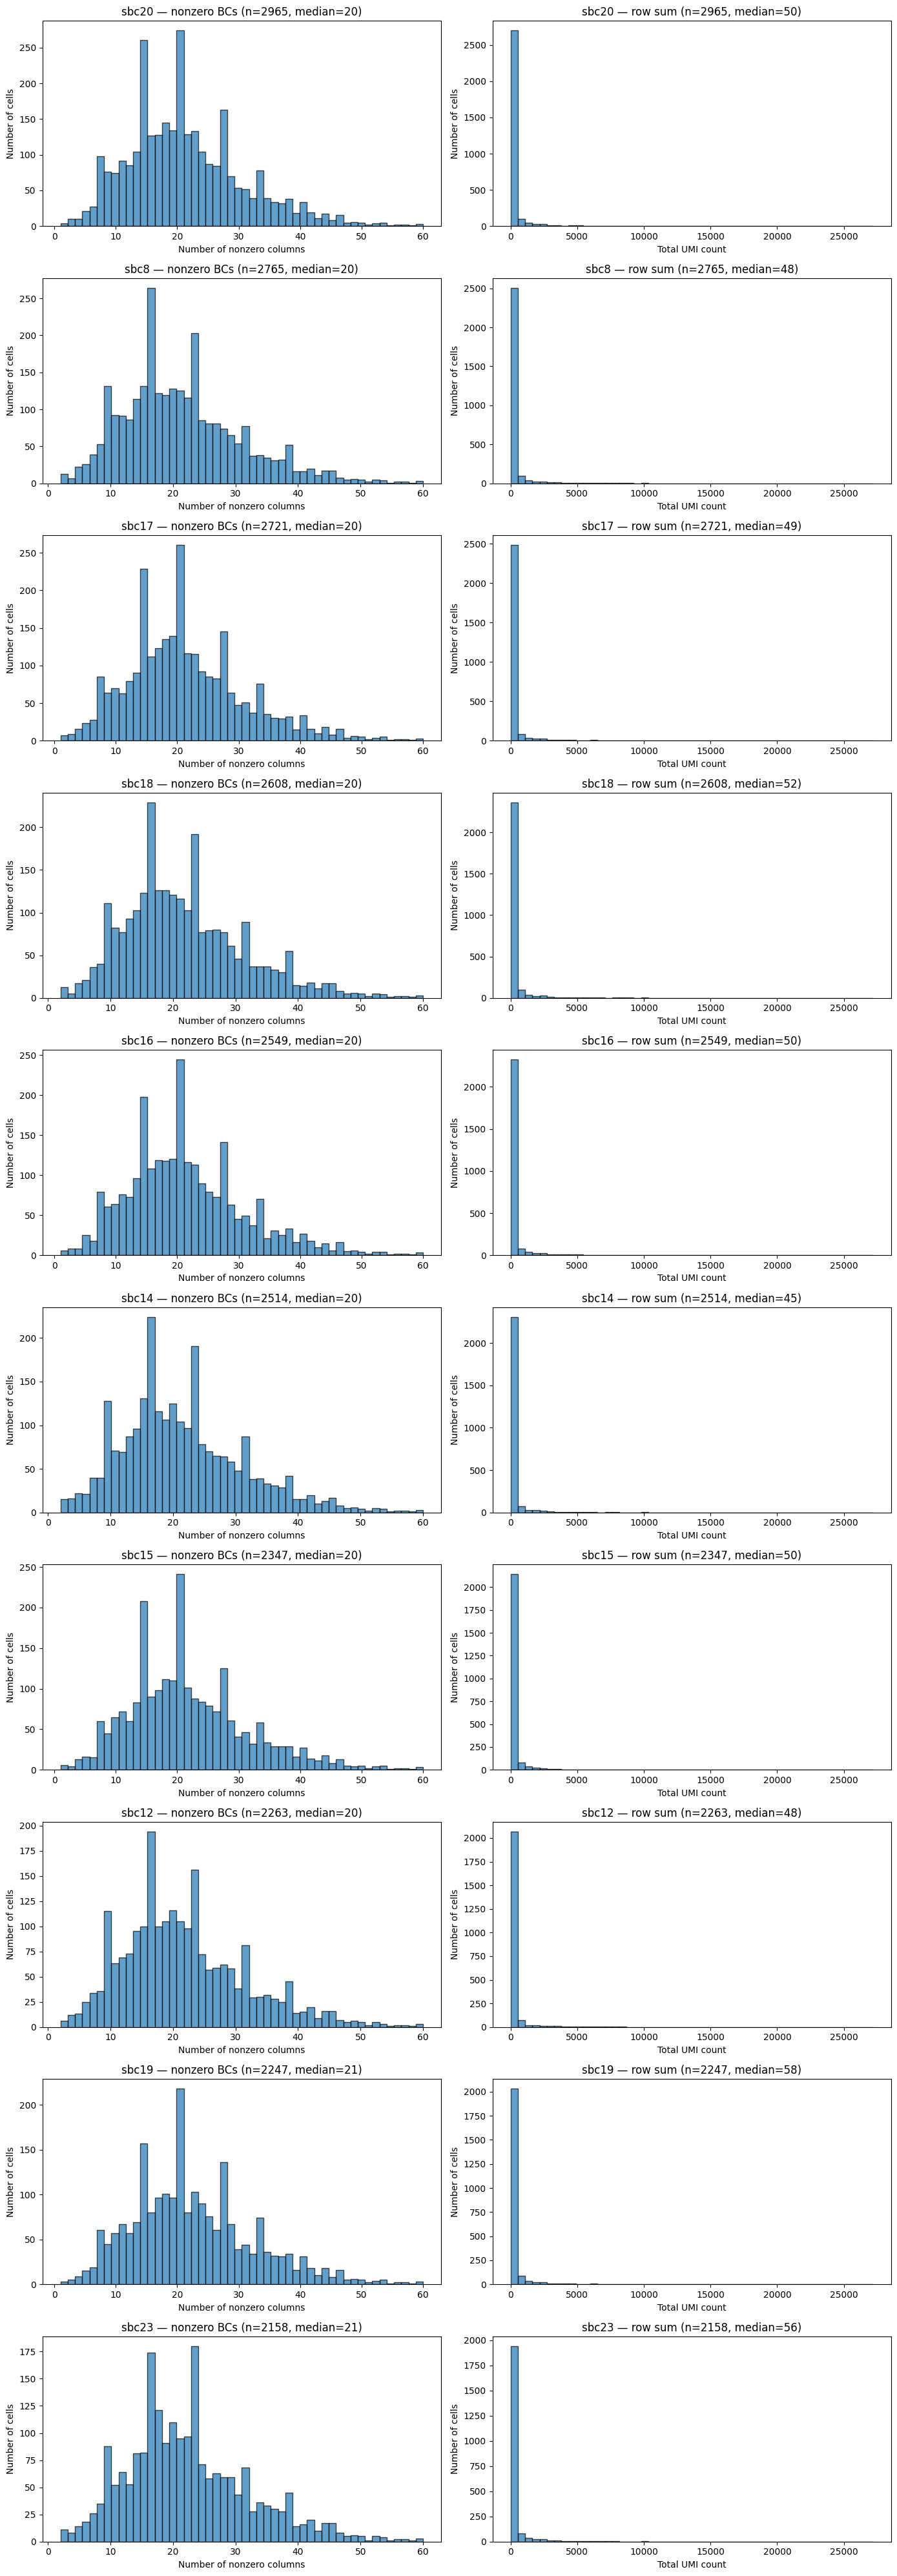

In [ ]:
# Loop through all BCs
fig, axes = plt.subplots(k_top, 2, figsize=(14, 4 * k_top))

for row_idx, bc in enumerate(top_k_bcs):
    mask = prot_DF_filtered[bc] > 0
    nonzero_topk = nonzero_per_row[mask]
    sum_topk = sum_per_row[mask]

    axes[row_idx, 0].hist(nonzero_topk, bins=50, edgecolor="black", alpha=0.7)
    axes[row_idx, 0].set_xlabel("Number of nonzero columns")
    axes[row_idx, 0].set_ylabel("Number of cells")
    axes[row_idx, 0].set_title(f"{bc} — nonzero BCs (n={mask.sum()}, median={int(nonzero_topk.median())})")

    axes[row_idx, 1].hist(sum_topk, bins=50, edgecolor="black", alpha=0.7)
    axes[row_idx, 1].set_xlabel("Total UMI count")
    axes[row_idx, 1].set_ylabel("Number of cells")
    axes[row_idx, 1].set_title(f"{bc} — row sum (n={mask.sum()}, median={sum_topk.median():.0f})")

plt.tight_layout()
plt.show()

# Demux alg

In [ ]:
from spatial_barcode_demux import demux_all_cells, plot_cell

In [ ]:
non_conf_mask = xy_raw["label"] == "non-confident"
non_conf_idx = xy_raw.index[non_conf_mask]
conf_idx = xy_raw.index[~non_conf_mask]
print(f"Confident: {len(conf_idx)}, Non-confident: {len(non_conf_idx)}")

demux_df = demux_all_cells(prot_DF_filtered.loc[non_conf_idx], threshold_k=float(CONFIG['demux']['threshold_k']))

demux_xy = demux_df[["cell", "x", "y"]].copy()
demux_xy["label"] = "non-confident"
demux_xy = demux_xy.set_index("cell")

xy_raw = pd.concat([xy_raw.loc[conf_idx], demux_xy])

adata = mdata['rna'].copy()

adata.obs["spatial_x"] = xy_raw.reindex(adata.obs_names)["x"]
adata.obs["spatial_y"] = xy_raw.reindex(adata.obs_names)["y"]
adata.obs["spatial_label"] = xy_raw.reindex(adata.obs_names)["label"]
print(adata.obs[["spatial_x", "spatial_y", "spatial_label"]].head())
xy_raw

Confident: 2451, Non-confident: 2841
Half 1: 42 barcodes (sbc1 -> sbc42)
Half 2: 42 barcodes (sbc97 -> sbc138)
Total cells: 2841
Threshold multiplier: 2.0
Running demux...

Done! Results summary:
  Low confidence (<10%) -- half1: 636, half2: 924
  Fallback (no peaks) -- half1: 365, half2: 883
                   spatial_x spatial_y  spatial_label
AAACCAAAGGATGGCA-1      sbc5    sbc111      confident
AAACCAAAGTCGATCA-1     sbc15    sbc112      confident
AAACCAAAGTGAGCGA-1      sbc8    sbc124      confident
AAACCCGCAATTCGCC-1     sbc16    sbc124  non-confident
AAACCCGCACTATCCA-1      sbc3    sbc114      confident


,x,y,label
AAACCAAAGGATGGCA-1,sbc5,sbc111,confident
AAACCAAAGTCGATCA-1,sbc15,sbc112,confident
AAACCAAAGTGAGCGA-1,sbc8,sbc124,confident
AAACCCGCACTATCCA-1,sbc3,sbc114,confident
AAACGAATCCAGCGAT-1,sbc19,sbc120,confident
...,...,...,...
TGTGCCTCATGAGCCA-1,sbc5,sbc118,non-confident
TGTGGTCAGTTGGTCA-1,sbc18,sbc120,non-confident
TGTGGTTGTTGAGCGG-1,sbc17,sbc120,non-confident
TGTGTACGTGAGGCAT-1,sbc14,sbc121,non-confident


In [ ]:
from collections import Counter

# Count the occurrences of (x, y) pairs in xy_raw
pair_counts = xy_raw[["x", "y"]].value_counts().reset_index()
pair_counts.columns = ["x", "y", "count"]

# Sort by count descending for clarity
pair_counts = pair_counts.sort_values(by="count", ascending=False)

# Optionally display the top few
print(pair_counts.head())

       x       y  count
0  sbc18  sbc119     32
1  sbc17  sbc118     29
2  sbc15  sbc120     29
3  sbc18  sbc118     28
4  sbc16  sbc118     27


In [ ]:
adata.obs['BC_counts'] = nonzero_per_row 
adata.obs['UMI_total'] = sum_per_row
adata

AnnData object with n_obs × n_vars = 5292 × 33696
    obs: 'spatial_x', 'spatial_y', 'spatial_label', 'BC_counts', 'UMI_total'
    var: 'gene_ids', 'feature_types', 'genome', 'pattern', 'read', 'sequence'

# PLot

In [ ]:
def pivot_xy_counts(xy_df):
    if xy_df.empty:
        return pd.DataFrame(0.0, index=list(df.index), columns=list(df.columns))
    heatmap_data = xy_df[["x", "y"]].value_counts().reset_index(
        name="count").pivot(index="x", columns="y", values="count").fillna(0)

    heatmap_data = heatmap_data.reindex(df.index).T.reindex(df.columns).T.fillna(0).T
    heatmap_data.index, heatmap_data.columns = heatmap_data.columns, heatmap_data.index
    return heatmap_data

def split_cell(val):
    """Split val into 2×2 patch of integers that sum exactly to val."""
    base = val // 4
    remainder = val % 4
    # distribute remainder as 1s into the first `remainder` sub-cells
    patch = np.array([base, base, base, base])
    patch[:remainder] += 1
    return patch.reshape(2, 2)

def double_matrix_conserved(df):
    A = df.values
    N, M = A.shape
    B = np.zeros((2*N, 2*M), dtype=A.dtype)
    for i in range(N):
        for j in range(M):
            val = int(A[i, j])
            base = val // 4
            remainder = val % 4
            patch = np.array([base, base, base, base])
            patch[:remainder] += 1
            B[2*i:2*i+2, 2*j:2*j+2] = patch.reshape(2, 2)

    new_rows = [idx for idx in df.index   for _ in range(2)]
    new_cols = [col for col in df.columns for _ in range(2)]

    return pd.DataFrame(B, index=new_rows, columns=new_cols)

xy_nn = xy_raw.dropna(subset=["x", "y"])

# remove sbc1 and sbc97
xy_nn = xy_nn[~((xy_nn['x'] == 'sbc1') | (xy_nn['y'] == 'sbc97'))]


In [ ]:
xy_raw

,x,y,label
AAACCAAAGGATGGCA-1,sbc5,sbc111,confident
AAACCAAAGTCGATCA-1,sbc15,sbc112,confident
AAACCAAAGTGAGCGA-1,sbc8,sbc124,confident
AAACCCGCACTATCCA-1,sbc3,sbc114,confident
AAACGAATCCAGCGAT-1,sbc19,sbc120,confident
...,...,...,...
TGTGCCTCATGAGCCA-1,sbc5,sbc118,non-confident
TGTGGTCAGTTGGTCA-1,sbc18,sbc120,non-confident
TGTGGTTGTTGAGCGG-1,sbc17,sbc120,non-confident
TGTGTACGTGAGGCAT-1,sbc14,sbc121,non-confident


In [ ]:
from matplotlib.colors import LinearSegmentedColormap

# take plasma and replace the bottom color with blue
plasma = plt.cm.plasma
colors = plasma(np.linspace(0, 1, 256))
colors[0] = [0, 0, 1, 1]  # RGBA blue at the bottom
custom_cmap = LinearSegmentedColormap.from_list("plasma_blue", colors)


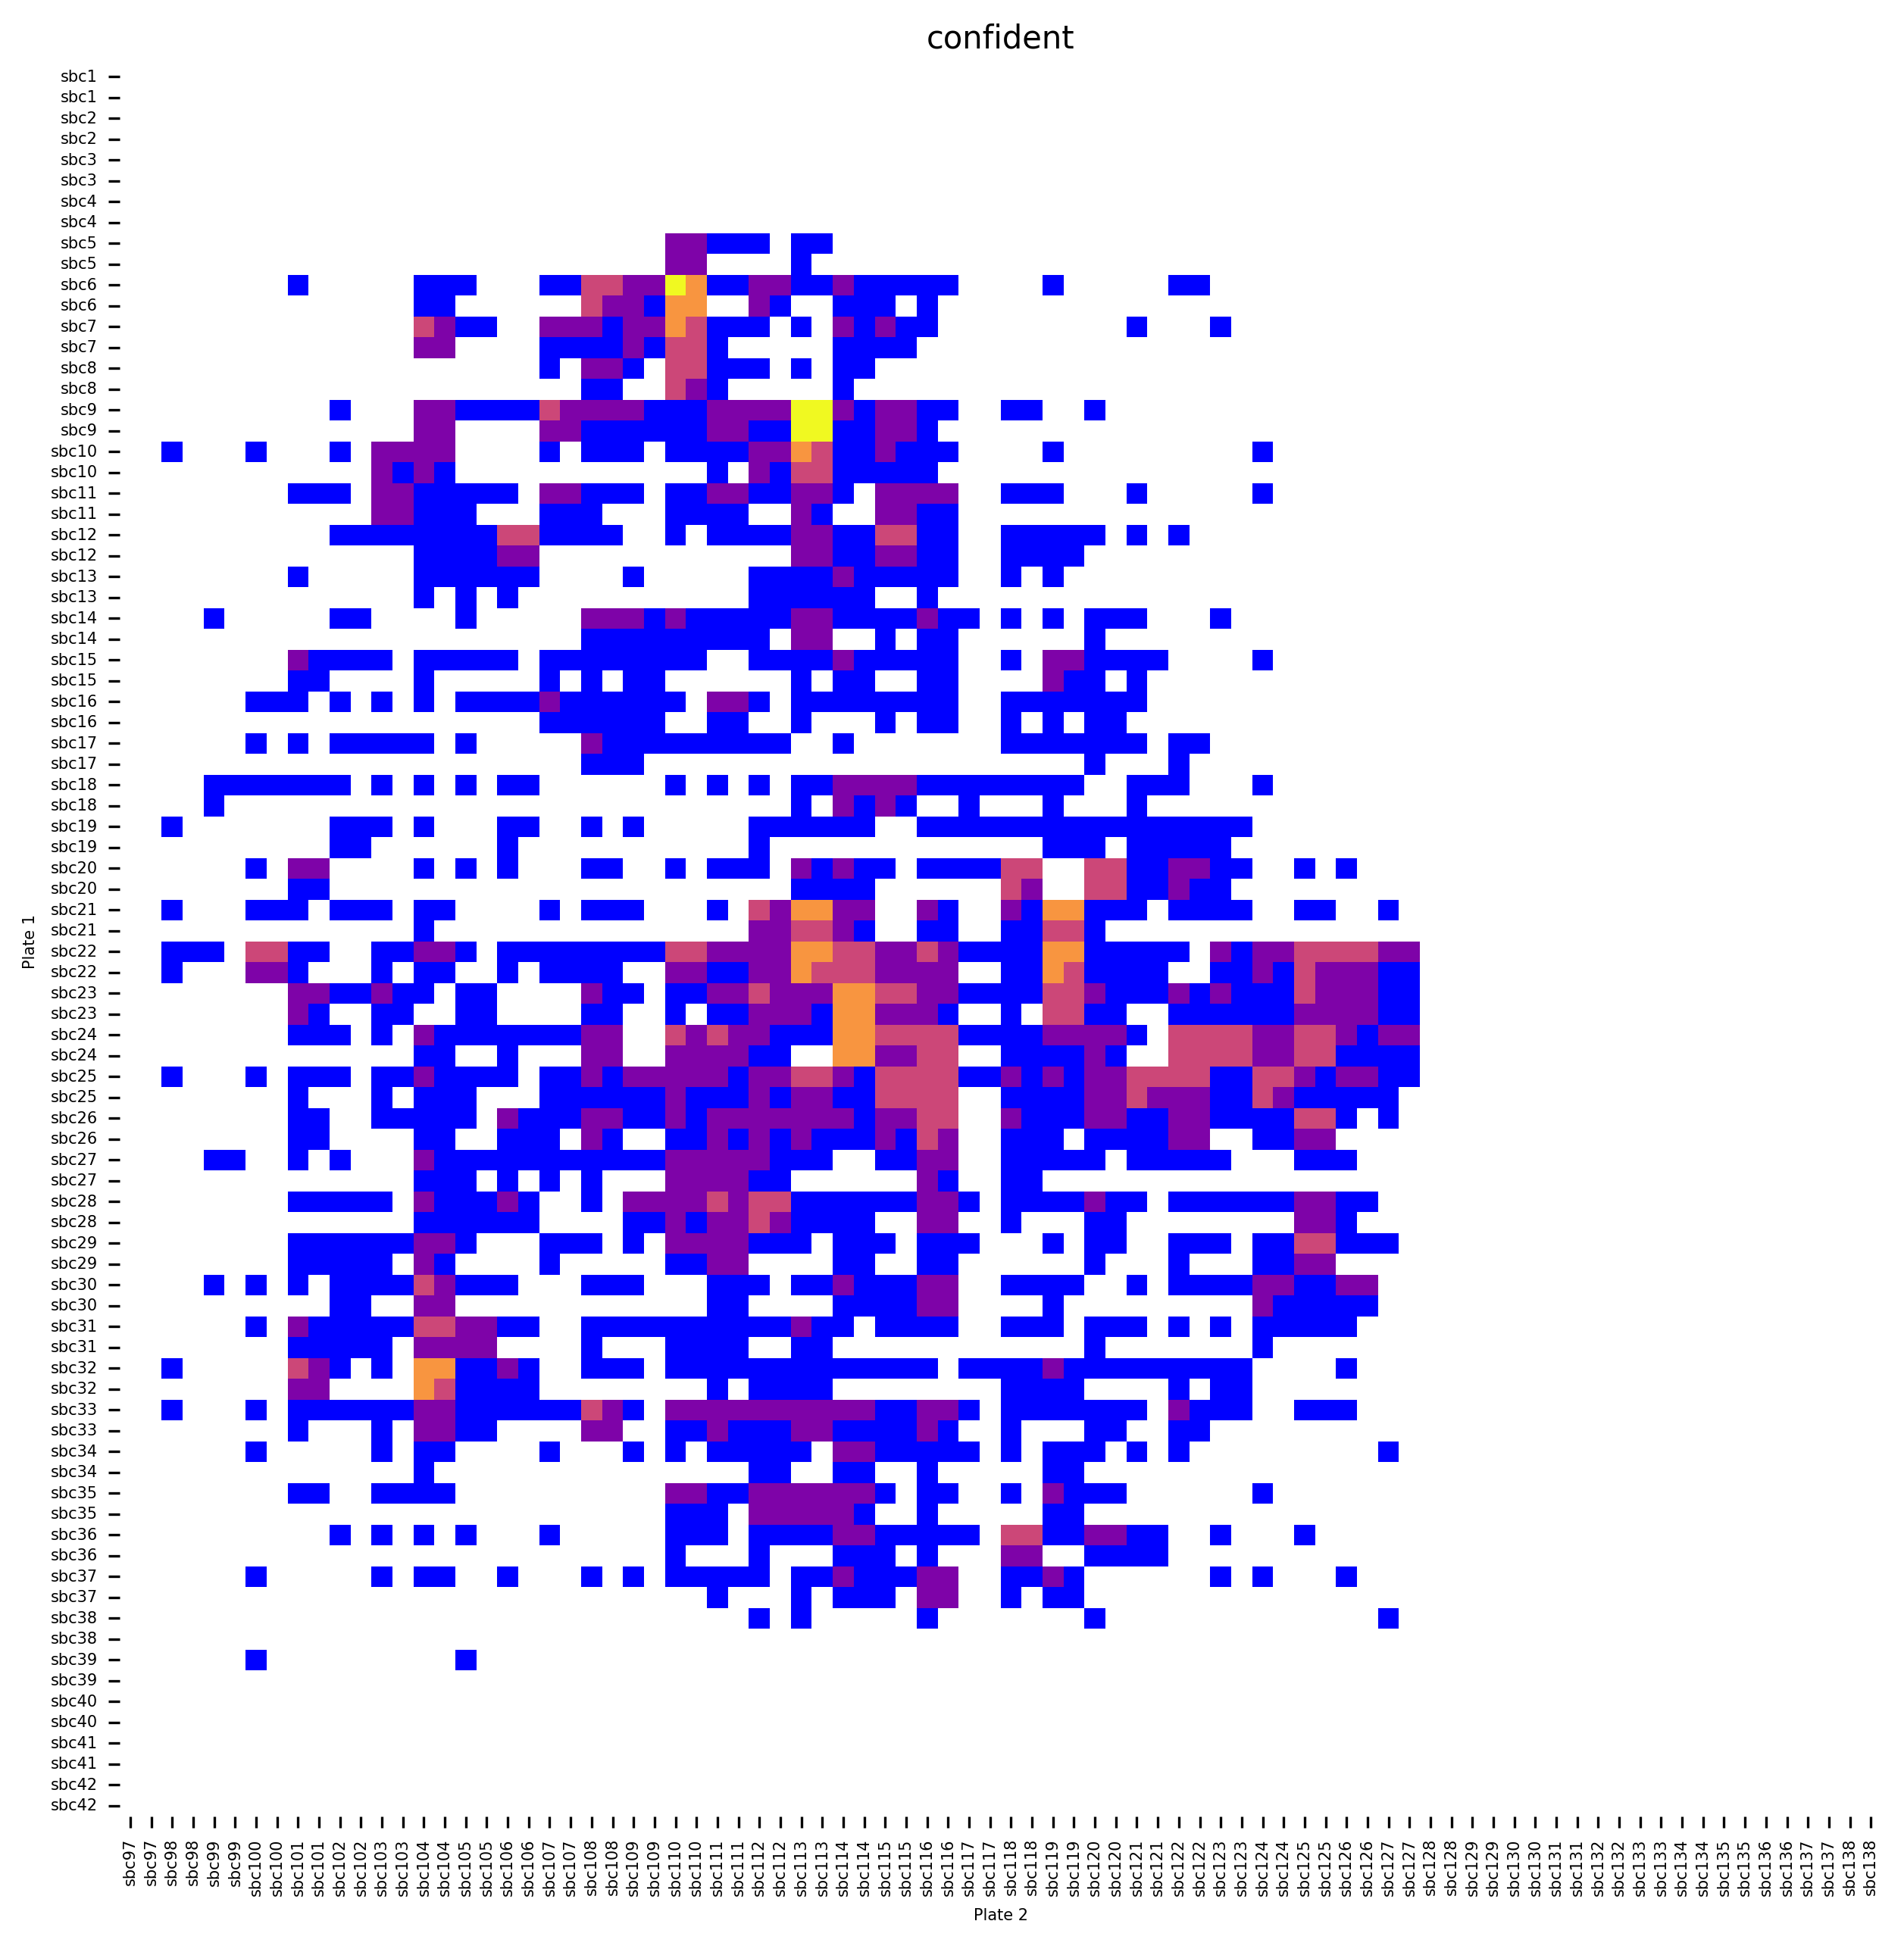

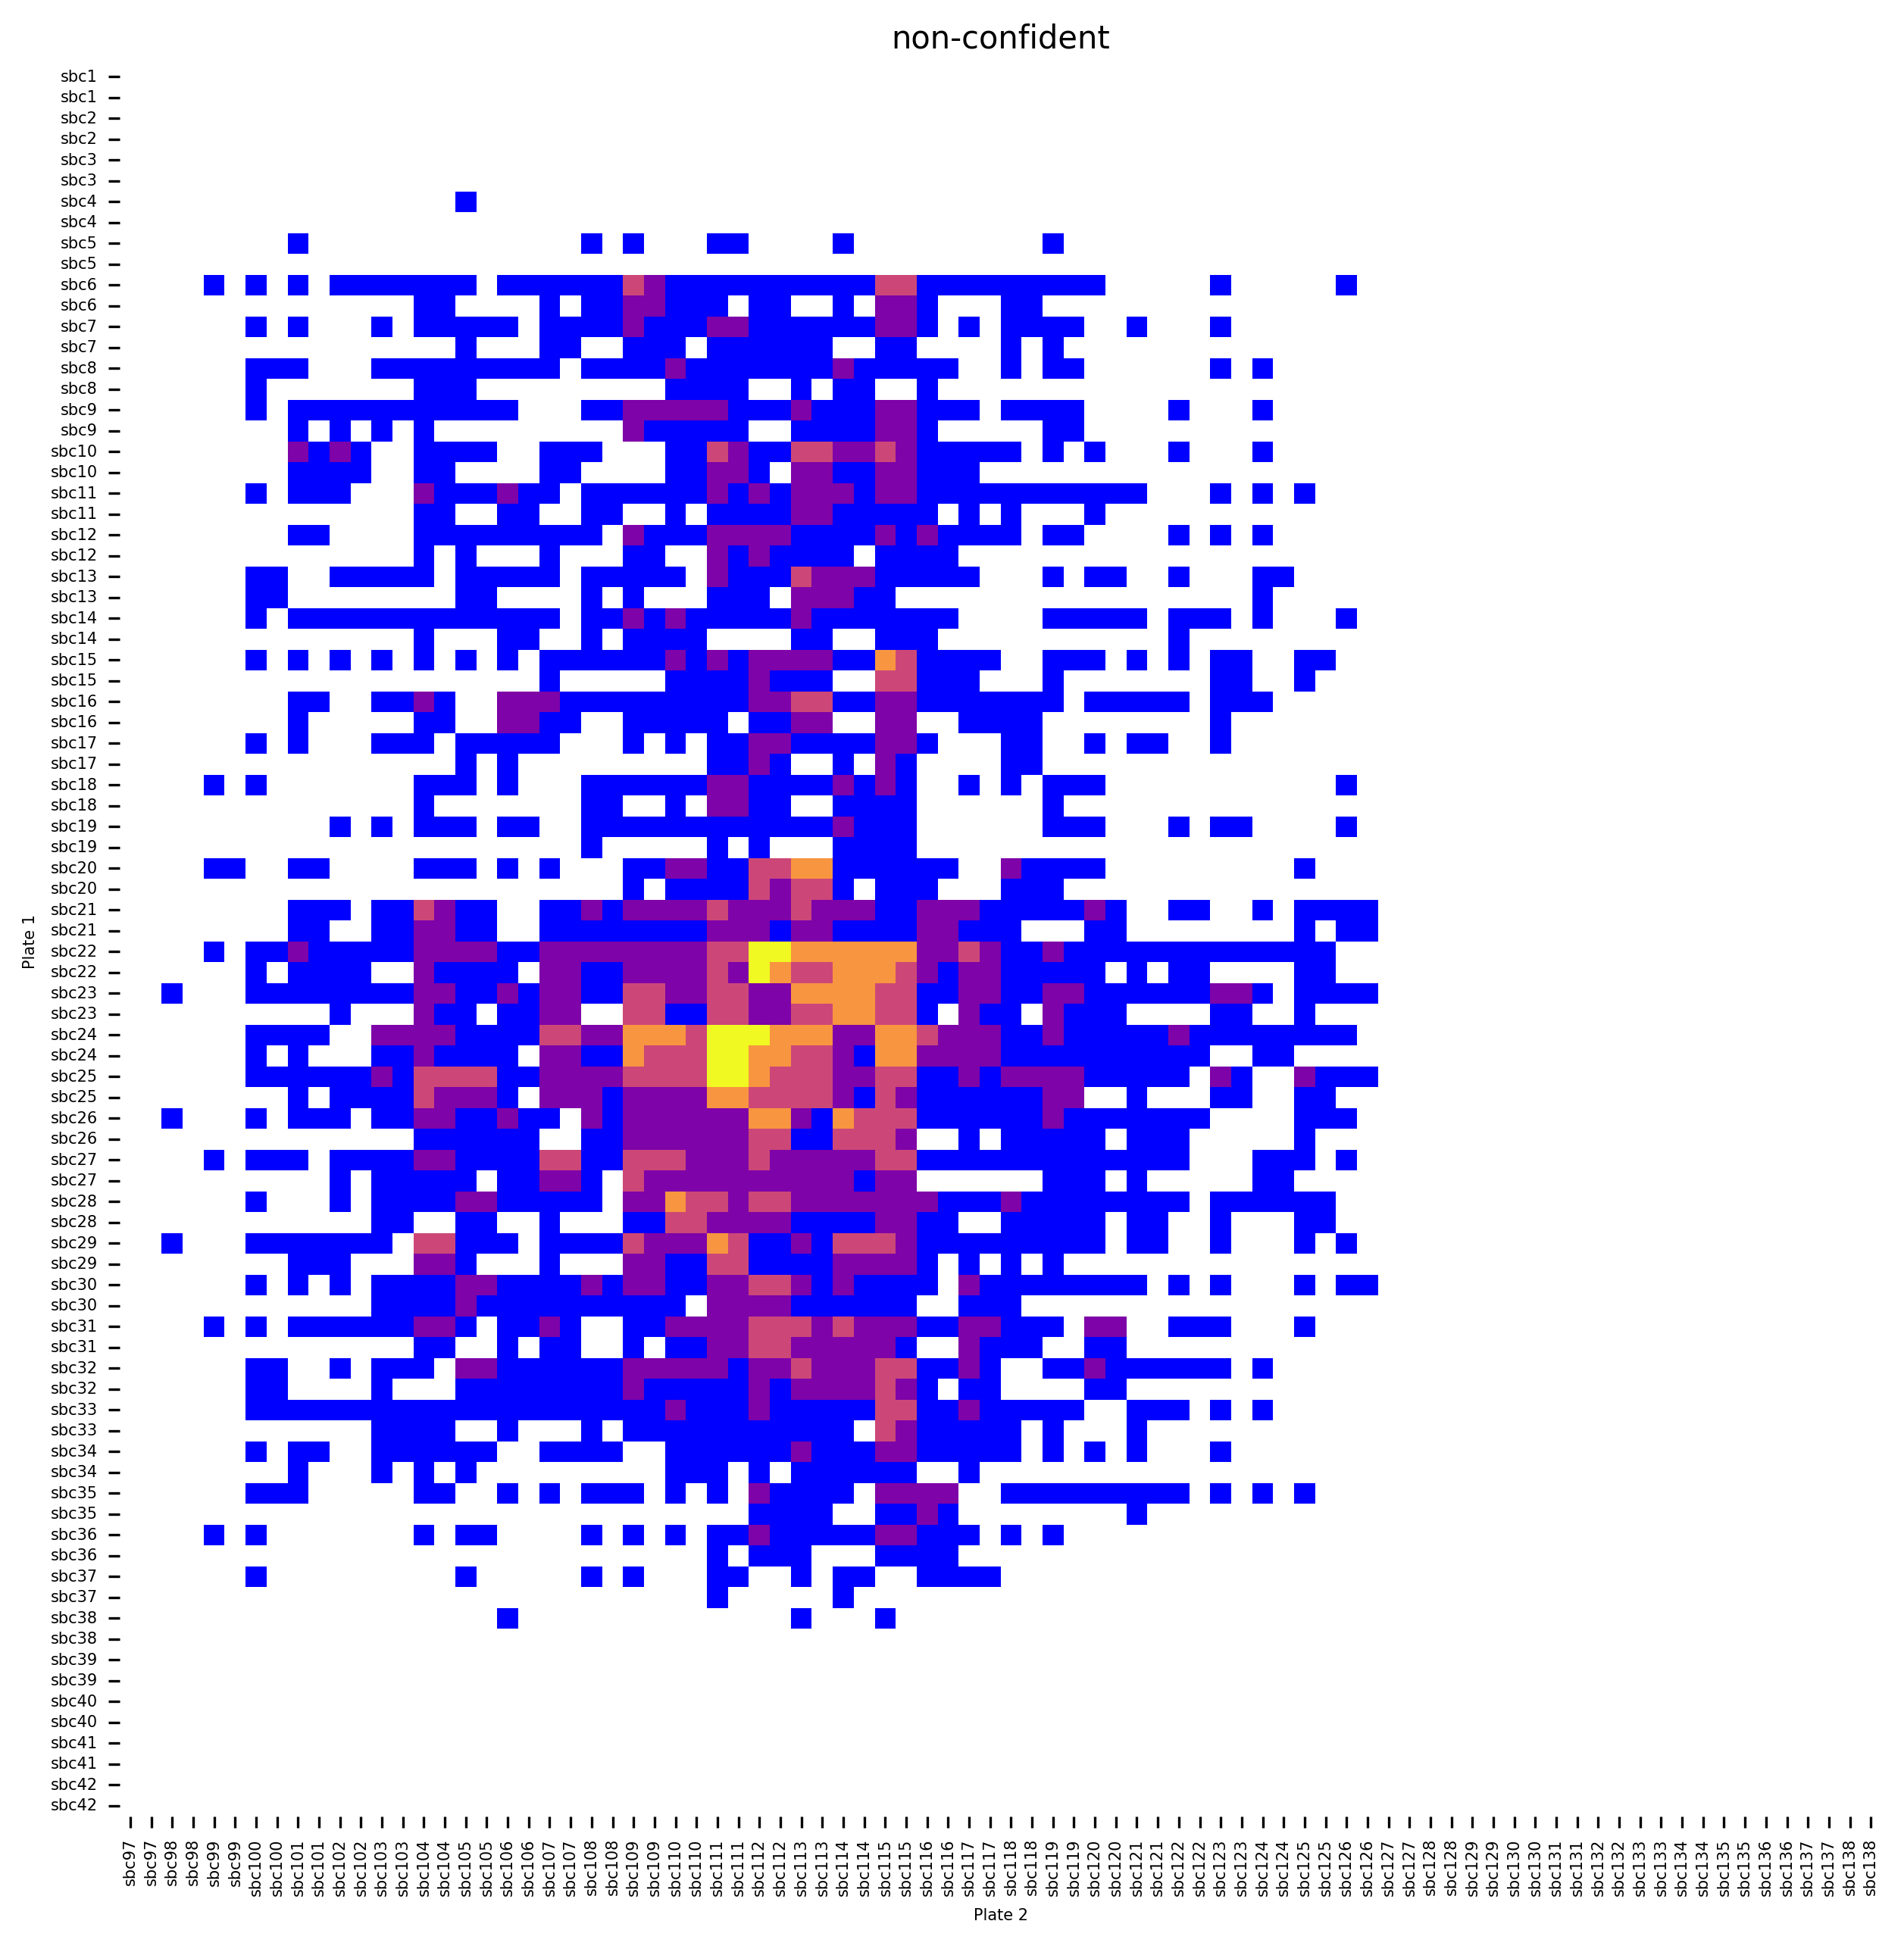

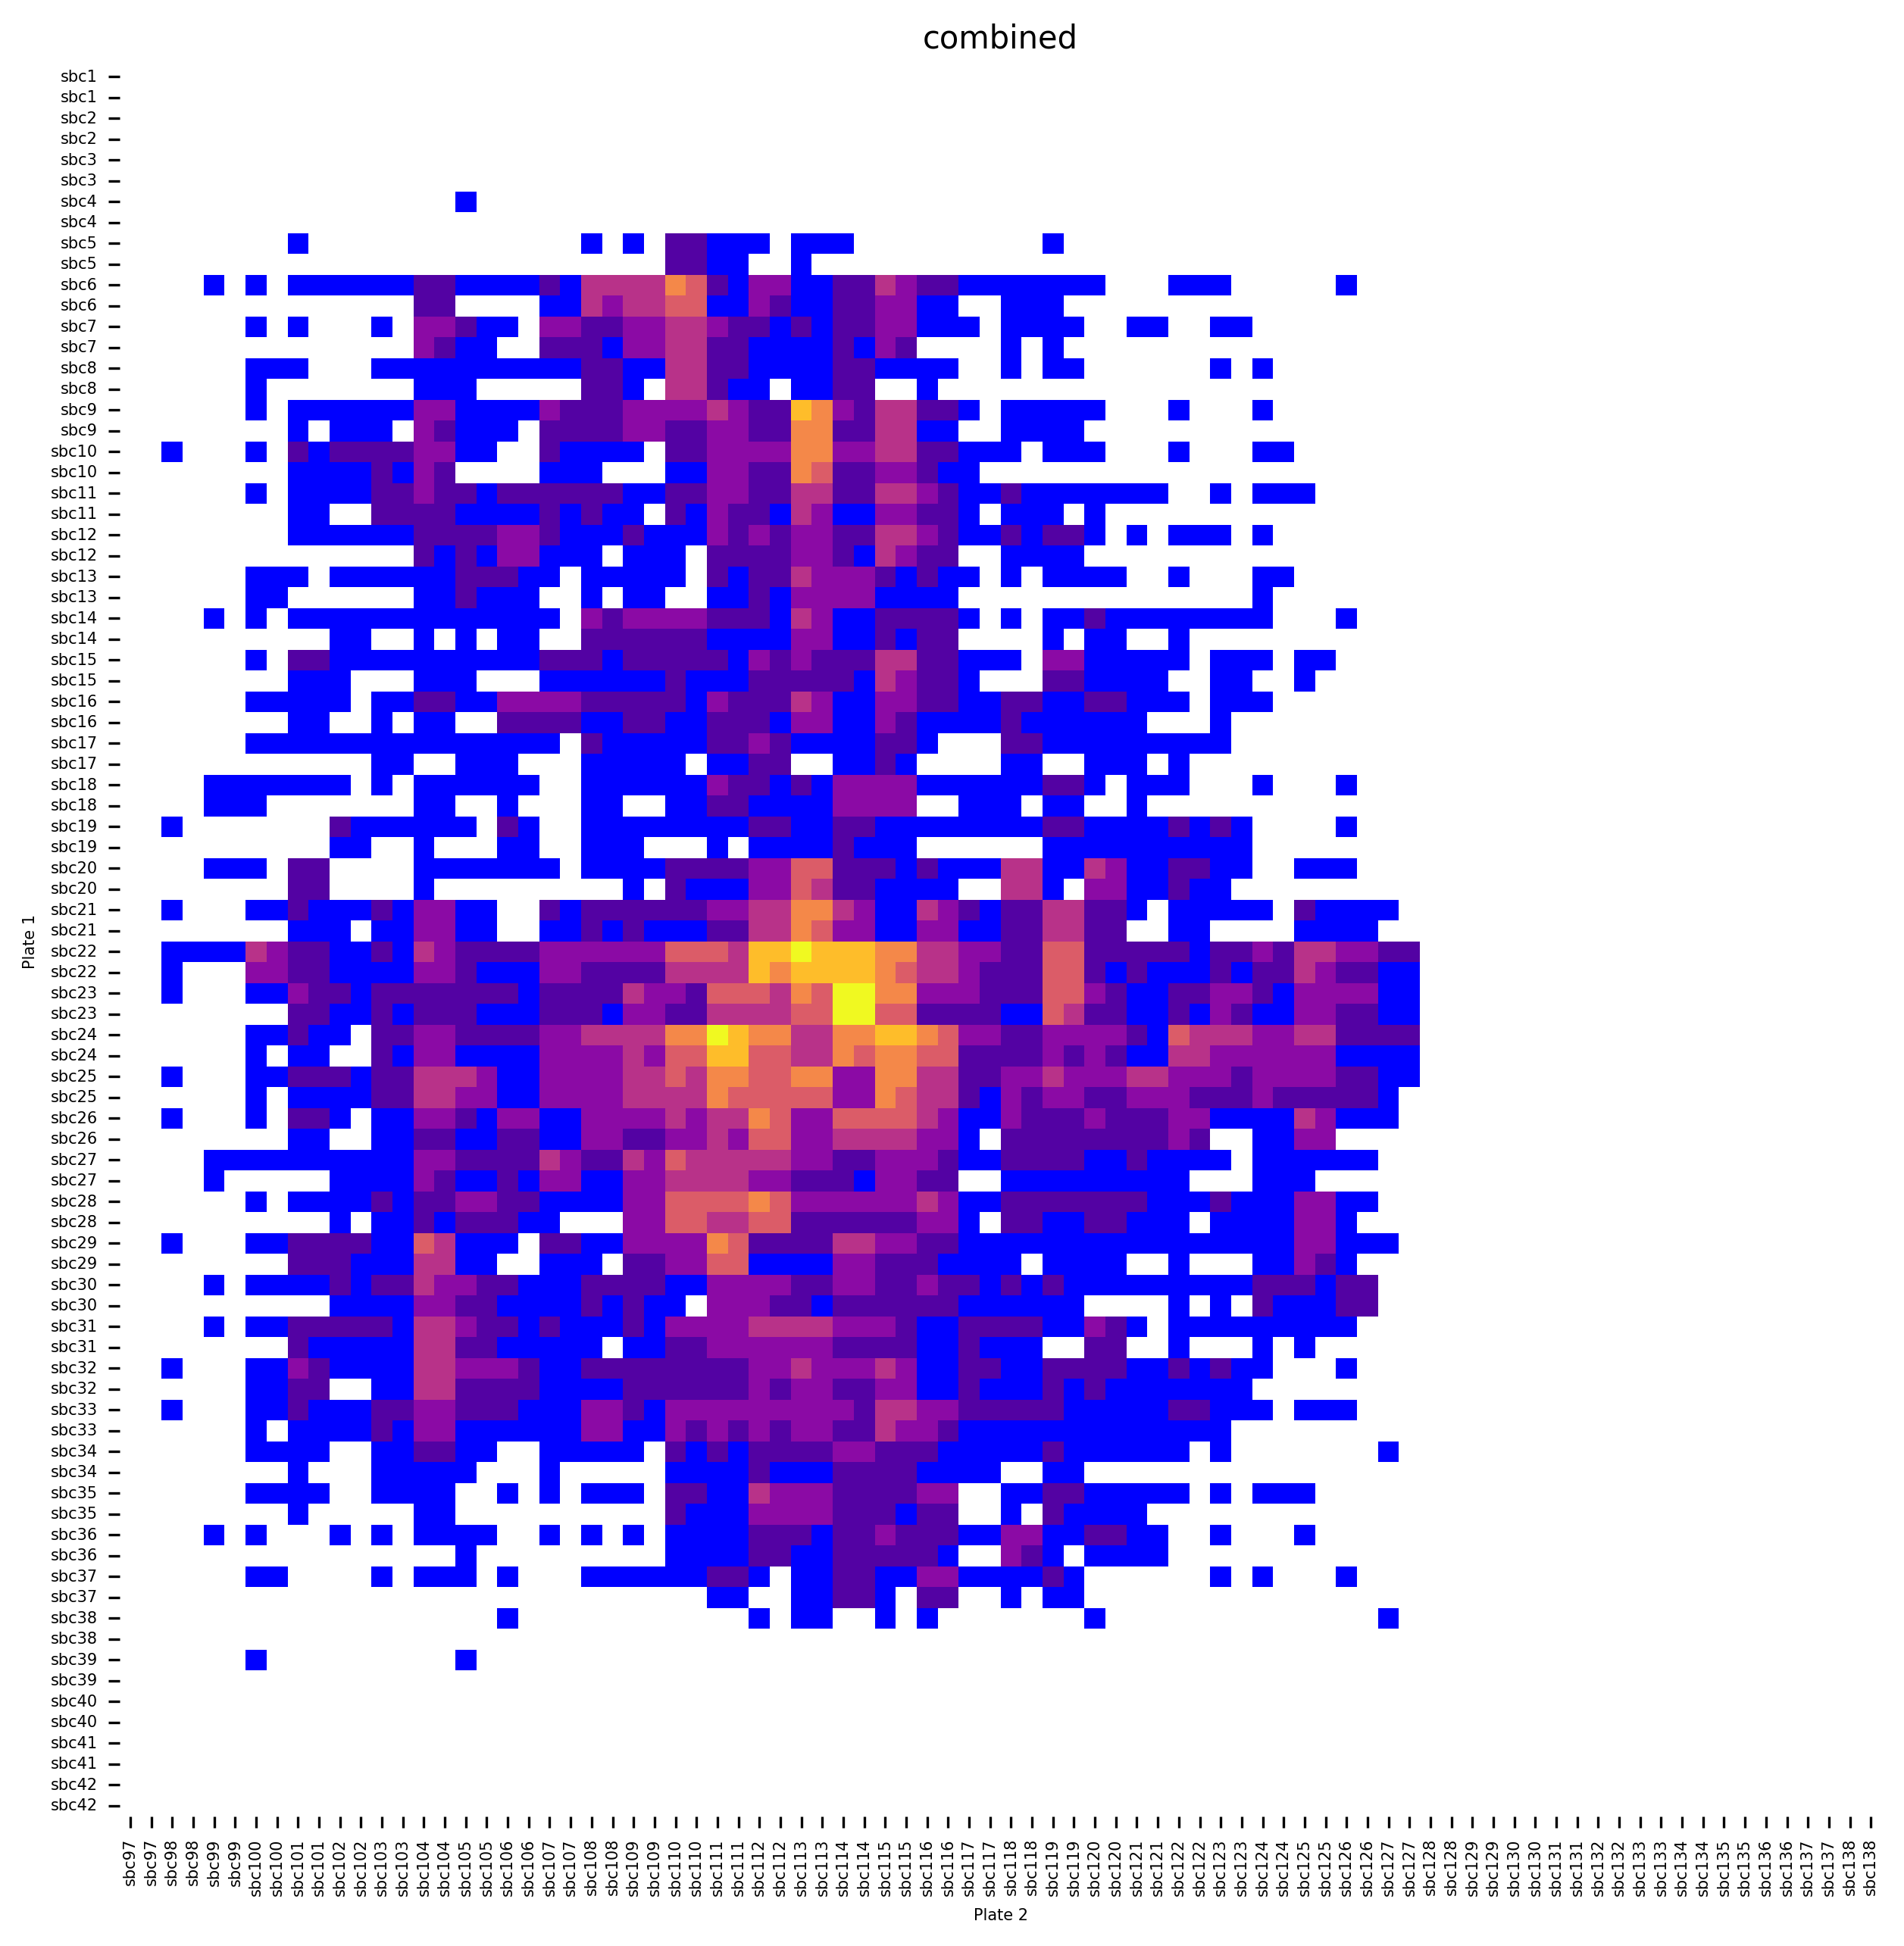

In [ ]:

for lab, sub in [
    ("confident", xy_nn[xy_nn["label"] == "confident"]),
    ("non-confident", xy_nn[xy_nn["label"] == "non-confident"]),
    ("combined", xy_nn),
]:
    plt.figure(figsize=(10, 10), dpi=300)
    heatmap_data = pivot_xy_counts(sub)
    heatmap_data = double_matrix_conserved(heatmap_data)

    heatmap_masked = heatmap_data.copy().astype(float)
    heatmap_masked[heatmap_masked == 0] = np.nan

    sns.heatmap(
        heatmap_masked,
        annot=False,
        fmt=".1f",
        square=False,
        cbar=False,
        cmap=custom_cmap,
        annot_kws={"size": 5},
        xticklabels=1,
        yticklabels=1,
        # linewidths=0.001,
    )

    plt.gca().set_facecolor('white')

    plt.xticks(fontsize=5)
    plt.yticks(fontsize=5)
    plt.xlabel("Plate 2", fontsize=5)
    plt.ylabel("Plate 1", fontsize=5)
    plt.title(lab, fontsize=10)
    # plt.tight_layout()
    fname = f"{CONFIG['output']['heatmap_prefix']}_" + lab.replace("-", "_") + ".png"
    plt.savefig(fname, dpi=300)
    plt.show()

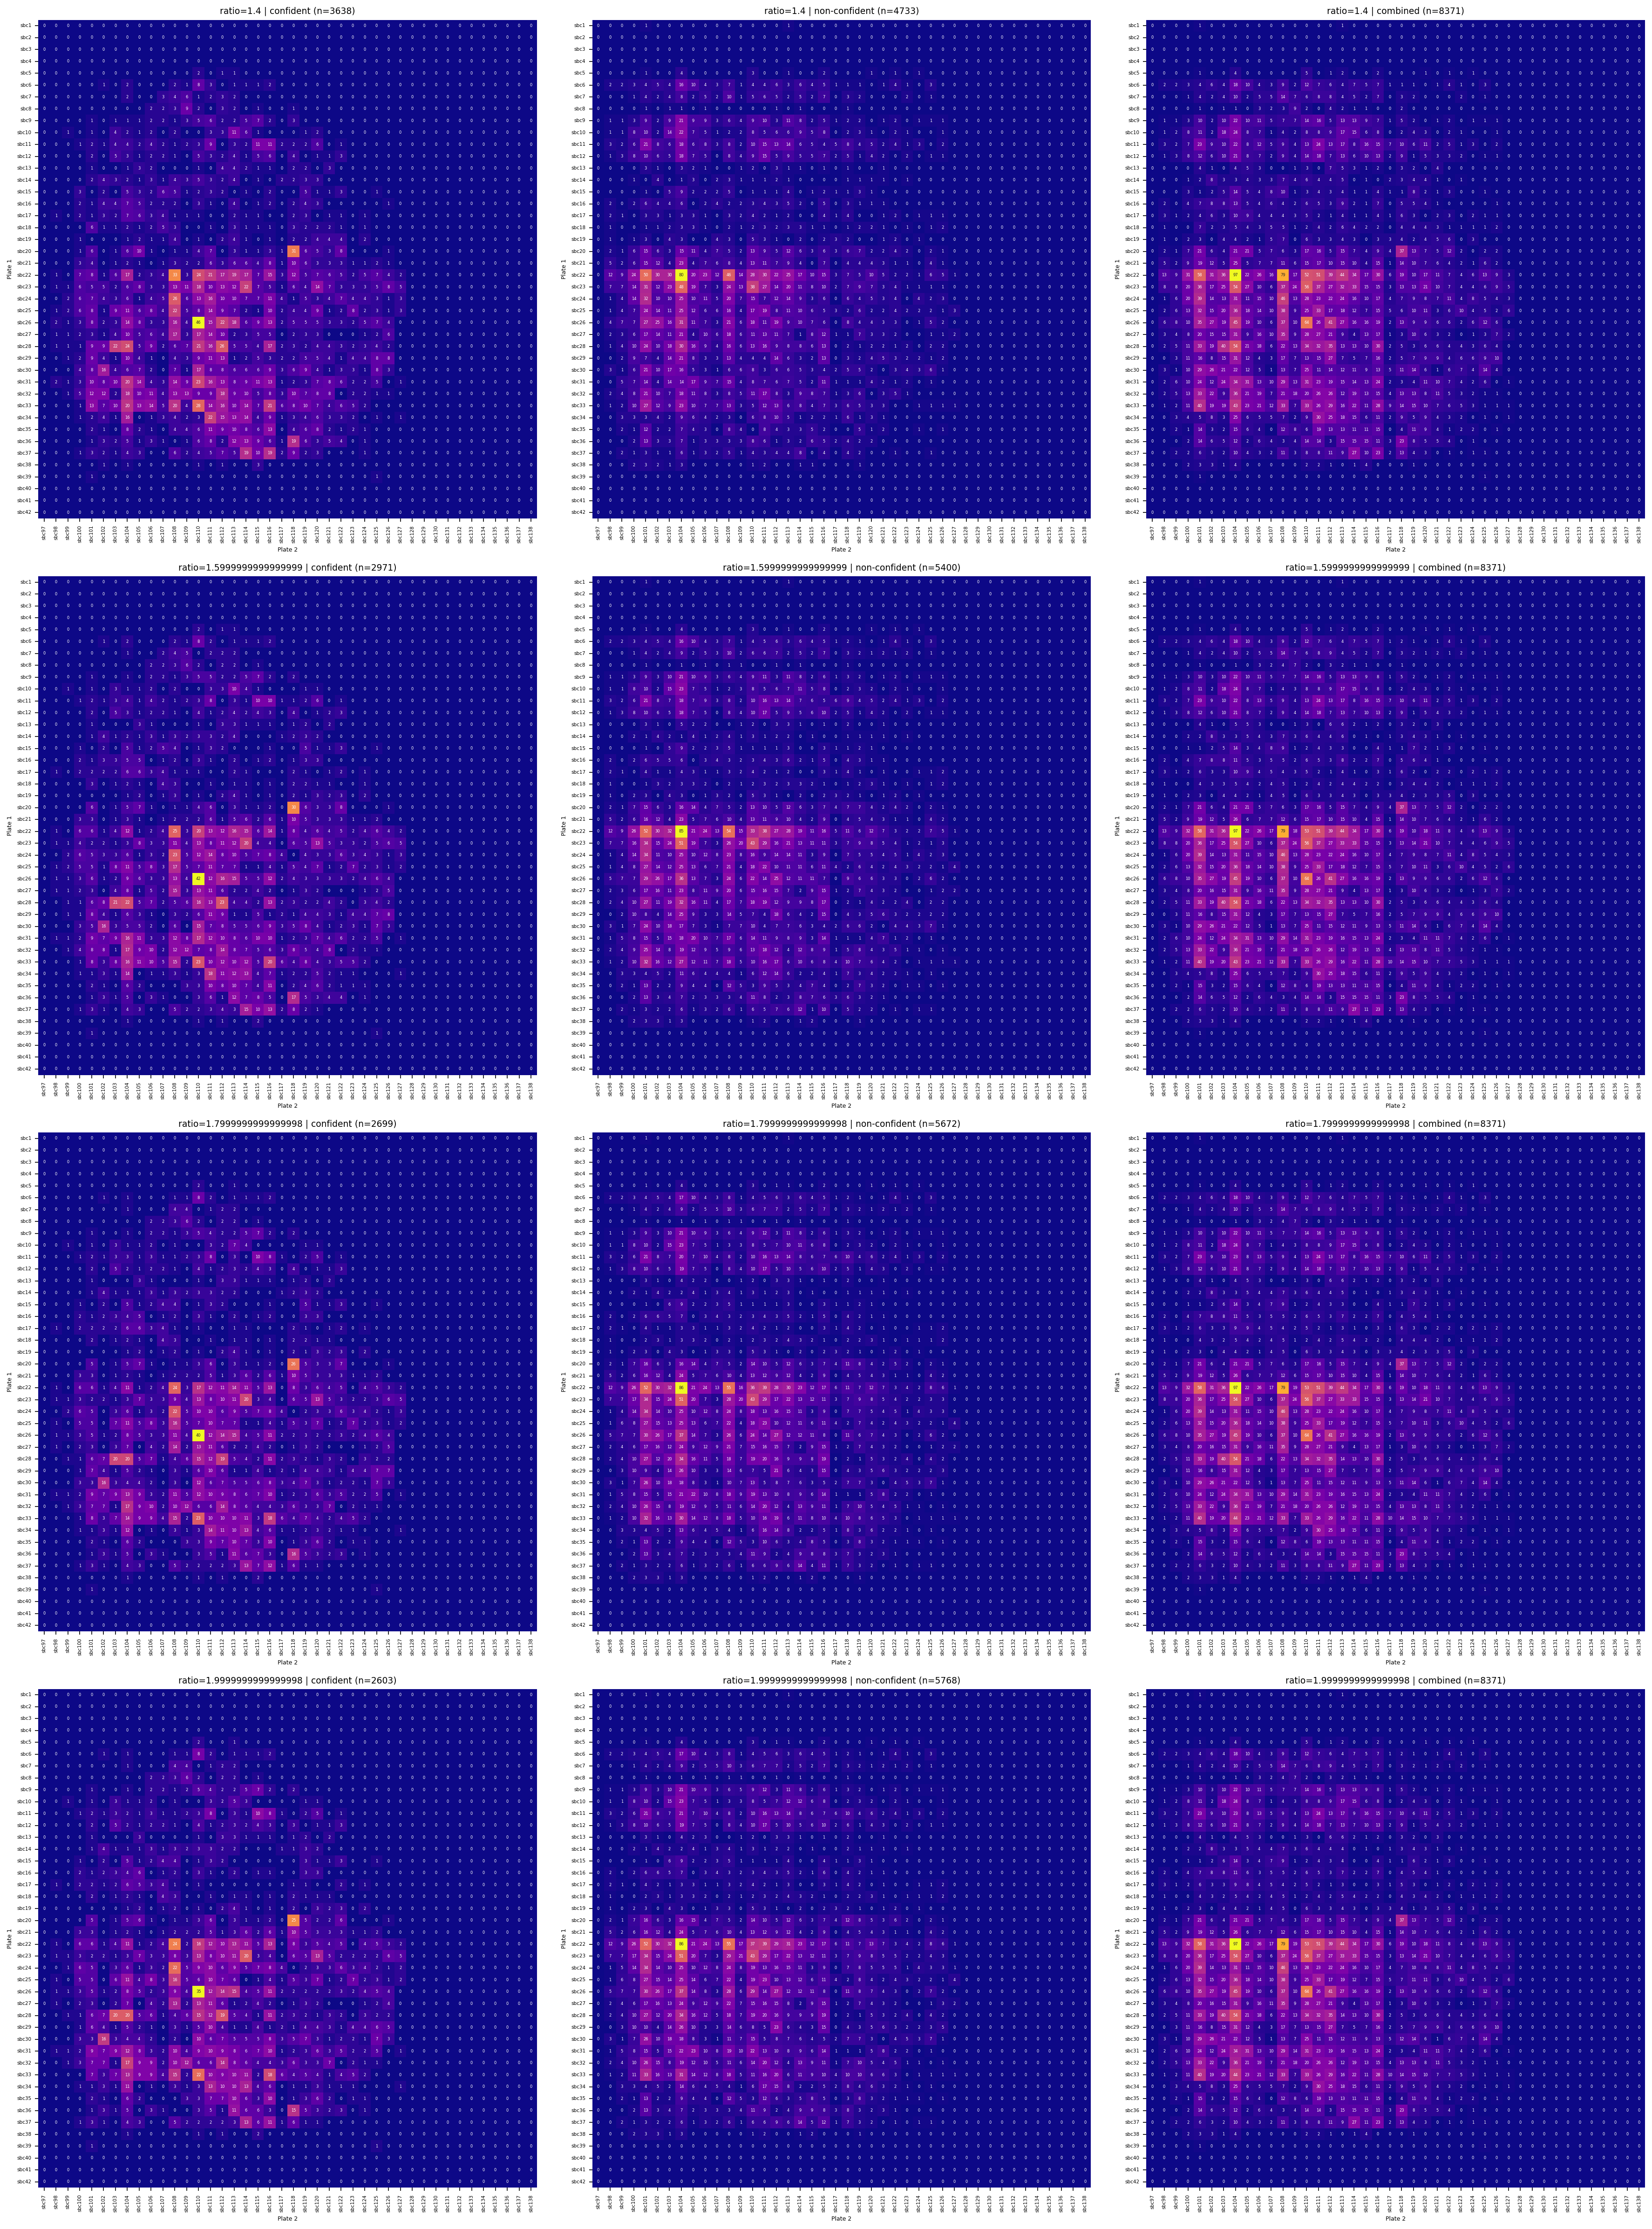

 ratio  confident  non_confident  confident/non_confident
   1.4       3638           4733                 0.768646
   1.6       2971           5400                 0.550185
   1.8       2699           5672                 0.475846
   2.0       2603           5768                 0.451283


In [ ]:
ratio_list = np.arange(
    float(CONFIG['ratio_grid']['start']),
    float(CONFIG['ratio_grid']['stop']),
    float(CONFIG['ratio_grid']['step']),
)

fig, axes = plt.subplots(
    nrows=len(ratio_list),
    ncols=3,
    figsize=(24, 8 * len(ratio_list)),
    dpi=150,
)
if len(ratio_list) == 1:
    axes = np.array([axes])

summary_rows = []
confidence_by_ratio = {}

for row_i, r in enumerate(ratio_list):
    xs, ys, labs = [], [], []
    for bc in prot_DF_filtered.index:
        name_x, cx, _, _ = _top_name_and_confident(
            prot_DF_filtered.loc[bc, rows], rows, r,
            suspect_sbcs=suspect_list, suspect_multiplier=suspect_multiplier,
        )
        name_y, cy, _, _ = _top_name_and_confident(
            prot_DF_filtered.loc[bc, cols], cols, r,
            suspect_sbcs=suspect_list, suspect_multiplier=suspect_multiplier,
        )
        xs.append(name_x)
        ys.append(name_y)
        labs.append("confident" if (cx and cy) else "non-confident")

    xy_r = pd.DataFrame(
        {"x": xs, "y": ys, "label": labs},
        index=prot_DF_filtered.index,
    ).dropna(subset=["x", "y"])

    col_name = f"confident_r{float(r):.1f}"
    confidence_by_ratio[col_name] = (
        xy_r["label"].eq("confident").map({True: "yes", False: "no"})
    )

    n_conf = int((xy_r["label"] == "confident").sum())
    n_nonconf = int((xy_r["label"] == "non-confident").sum())
    ratio_c_nc = (n_conf / n_nonconf) if n_nonconf else np.nan
    summary_rows.append({
        "ratio": r,
        "confident": n_conf,
        "non_confident": n_nonconf,
        "confident/non_confident": ratio_c_nc,
    })

    subsets = [
        ("confident", xy_r[xy_r["label"] == "confident"]),
        ("non-confident", xy_r[xy_r["label"] == "non-confident"]),
        ("combined", xy_r),
    ]
    for col_i, (lab, sub) in enumerate(subsets):
        ax = axes[row_i, col_i]
        heatmap_data = pivot_xy_counts(sub)
        sns.heatmap(
            heatmap_data,
            annot=True,
            fmt=".0f",
            cmap="plasma",
            square=True,
            cbar=False,
            annot_kws={"size": 4},
            xticklabels=1,
            yticklabels=1,
            ax=ax,
        )
        ax.tick_params(axis="x", labelsize=5)
        ax.tick_params(axis="y", labelsize=5)
        ax.set_xlabel("Plate 2", fontsize=6)
        ax.set_ylabel("Plate 1", fontsize=6)
        ax.set_title(f"ratio={r} | {lab} (n={len(sub)})", fontsize=9)

plt.tight_layout()
plt.savefig(path + '//' + CONFIG['output']['ratio_grid_plot'].format(sample_id=sample_id), dpi=200)
plt.show()

ratio_summary = pd.DataFrame(summary_rows)
print(ratio_summary.to_string(index=False))

confidence_by_ratio_df = pd.DataFrame(confidence_by_ratio)
confidence_by_ratio_df = confidence_by_ratio_df.reindex(prot_DF_filtered.index)


In [ ]:
print(len(xy_nn[xy_nn["label"] == "confident"]))
print(len(xy_nn[xy_nn["label"] == "non-confident"]))

2603
6066


In [ ]:
spatial_mask = adata.obs["spatial_x"].notna() & adata.obs["spatial_y"].notna()
adata_sp = adata[spatial_mask].copy()

rows = sorted(adata_sp.obs["spatial_x"].unique(), key=lambda s: int(''.join(filter(str.isdigit, s))))
cols = sorted(adata_sp.obs["spatial_y"].unique(), key=lambda s: int(''.join(filter(str.isdigit, s))))
if not ascend:
    # rows = rows[::-1]
    cols = cols[::-1]

row_map = {bc: i + 1 for i, bc in enumerate(rows)}
col_map = {bc: i + 1 for i, bc in enumerate(cols)}
coords_x = adata_sp.obs["spatial_x"].map(row_map).values.astype(float)
coords_y = adata_sp.obs["spatial_y"].map(col_map).values.astype(float)

adata_sp.obs["spatial_coordinate_x"] = coords_x
adata_sp.obs["spatial_coordinate_y"] = coords_y

jitter_radius = float(CONFIG['jitter_radius'])
pair_keys = list(zip(coords_x, coords_y))
from collections import defaultdict
group_indices = defaultdict(list)
for i, key in enumerate(pair_keys):
    group_indices[key].append(i)
for key, indices in group_indices.items():
    n = len(indices)
    if n <= 1:
        continue
    for rank, i in enumerate(indices):
        angle = 2 * np.pi * rank / n
        coords_x[i] += jitter_radius * np.cos(angle)
        coords_y[i] += jitter_radius * np.sin(angle)

adata_sp.obsm["X_spatial"] = np.column_stack([coords_x, coords_y])


In [ ]:

# fig, axes = plt.subplots(1, 2, figsize=(24, 10))

# sc.pl.embedding(adata_sp, basis="spatial", color="celltype", ax=axes[0], show=False, title="Spatial (celltype)")
# sc.pl.umap(adata_sp, color="celltype", ax=axes[1], show=False, title="UMAP (celltype)")

# plt.tight_layout()
# plt.show()

In [ ]:
adata_sp

AnnData object with n_obs × n_vars = 8669 × 33696
    obs: 'spatial_x', 'spatial_y', 'spatial_label', 'BC_counts', 'UMI_total', 'spatial_coordinate_x', 'spatial_coordinate_y'
    var: 'gene_ids', 'feature_types', 'genome', 'pattern', 'read', 'sequence'
    obsm: 'X_spatial'

In [ ]:
adata_sp.obs['spatial_x']

AAACCAAAGCTAGCCG-1    sbc19
AAACCAAAGGAGGCTA-1    sbc12
AAACCATTCCATAGTG-1    sbc10
AAACCATTCGAACGCT-1    sbc12
AAACCATTCGTTAGGC-1    sbc11
                      ...  
TGTGTACGTGCAGCCT-1    sbc25
TGTGTTAGTGATGAAT-1    sbc16
TGTGTTAGTTAGCCCA-1    sbc14
TGTGTTAGTTATGCGT-1    sbc14
TGTGTTGAGTCAGGAG-1     sbc1
Name: spatial_x, Length: 8669, dtype: object

In [ ]:
DF_coord = adata_sp.obs[['spatial_coordinate_x', 'spatial_coordinate_y']].copy()
DF_coord = DF_coord.join(xy_raw[["x", "y"]])
conf_cols = confidence_by_ratio_df.reindex(DF_coord.index).fillna('no')
DF_coord[conf_cols.columns] = conf_cols
DF_coord.to_csv(path + '//' + CONFIG['output']['coordinate_csv'].format(sample_id=sample_id))
DF_coord.head()

,spatial_coordinate_x,spatial_coordinate_y,x,y,confident_r1.4,confident_r1.6,confident_r1.8,confident_r2.0
AAACCAAAGCTAGCCG-1,19.0,9.0,sbc19,sbc107,yes,yes,yes,yes
AAACCAAAGGAGGCTA-1,12.0,12.0,sbc12,sbc110,yes,yes,yes,yes
AAACCATTCCATAGTG-1,10.0,30.0,sbc10,sbc128,yes,no,no,no
AAACCATTCGAACGCT-1,12.0,8.0,sbc12,sbc106,no,no,no,no
AAACCATTCGTTAGGC-1,11.0,28.0,sbc11,sbc126,yes,no,no,no


In [ ]:
adata_sp.write(path + '//' + CONFIG['output']['spatial_h5ad'].format(sample_id=sample_id))

In [ ]:
adata_sp.obsm['X_spatial']

array([[19.3       ,  9.        ],
       [12.3       , 12.        ],
       [10.3       , 30.        ],
       ...,
       [14.29517888, 21.94643293],
       [14.29664925, 30.95528732],
       [ 0.7       , 35.        ]], shape=(8669, 2))

In [ ]:
adata_sp

AnnData object with n_obs × n_vars = 8669 × 33696
    obs: 'spatial_x', 'spatial_y', 'spatial_label', 'BC_counts', 'UMI_total', 'spatial_coordinate_x', 'spatial_coordinate_y'
    var: 'gene_ids', 'feature_types', 'genome', 'pattern', 'read', 'sequence'
    obsm: 'X_spatial'

In [ ]:
xy_raw

,x,y,label
AAACCAAAGCTAGCCG-1,sbc19,sbc107,confident
AAACCAAAGGAGGCTA-1,sbc12,sbc110,confident
AAACGAATCCATCCTG-1,sbc24,sbc123,confident
AAACGACAGGCGTCCA-1,sbc18,sbc130,confident
AAACGATGTTATGGTC-1,sbc14,sbc116,confident
...,...,...,...
TGTGGTCAGTCATTGG-1,sbc4,sbc121,non-confident
TGTGGTTGTAACCCAT-1,sbc15,sbc108,non-confident
TGTGGTTGTCTAACTA-1,sbc14,sbc121,non-confident
TGTGGTTGTGAGCAGT-1,sbc13,sbc121,non-confident
